# Figure 1 schematics

Both conceptual panels for Figure 1, written so they can be rebuilt from scratch.
Neither uses recorded data — they state the paper's premise, and the evidence panels
sit elsewhere in the figure.

**1A, the open arena.** A 3D exploded stack: the cell-type representations that carry
environmental features, the map they compose, and the world those features belong to.
Two arrows separate the two steps the paper distinguishes — *compose* (cells to map)
and *register* (map to world). Anchoring is the second step, and it is what can fail
while the first stays intact.

**1B, the linear track.** The same argument in one dimension. Drawn as aligned panels
rather than a stack: in 2D the layers are planes, so an exploded view separates them
naturally, but in 1D they are curves and stacking them in 3D buries each behind the
next. One shared position axis lets a peak be traced from cell, through map, to the
feature of the track it represents.

**Conventions.**
- Rate maps are viridis, and carry **no frame** — they are data surfaces, and an
  outline competes with the coloured map above them without adding information.
- Colour means *feature identity* and belongs to the map and the world. The cell
  planes deliberately share one colormap so that nothing else in the figure claims
  colour as meaning.
- The map floor is a **bivariate** colour field: two colormaps combined, one along
  each axis, so every location carries its own signature. A map must say *where* you
  are, not merely that something salient is nearby.

## 1A — open arena

saved /Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/fig1A_stack.pdf


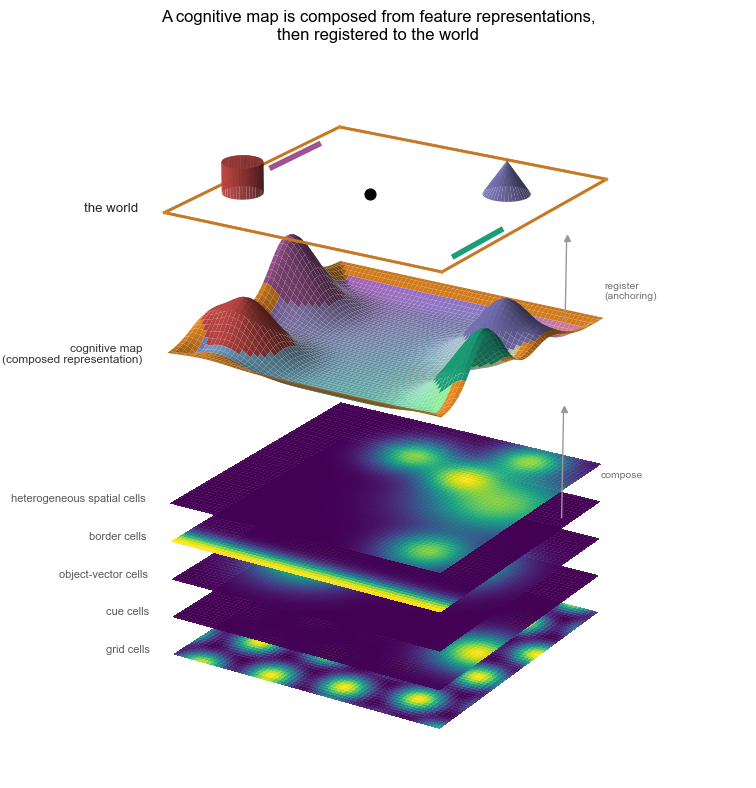

In [1]:
"""Figure 1A — layered view of how a cognitive map is assembled and registered.

Bottom: the cell-type representations that carry environmental features.
Middle: the high-dimensional map they compose, as a surface whose peaks mark
        salient features.
Top:    the world those features belong to.
"""
import sys, warnings, numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
sys.path.insert(0,'/Users/harryclark/Documents/spatial-manifolds/src')
from spatial_manifolds.anchoring import ANCH_COLOR, NONANCH_COLOR
plt.rcParams['font.family']='Arial'

N=64
g=np.linspace(-1,1,N); X,Y=np.meshgrid(g,g)
def gauss(cx,cy,s): return np.exp(-((X-cx)**2+(Y-cy)**2)/(2*s**2))

# ── the world: two objects, two wall cues ────────────────────────────────────
OBJS=[(-0.72,-0.55,'o'),(0.68,0.30,'^')]
CUES=[(-1.0,0.35),(1.0,-0.45)]

# ── cell-type layers ─────────────────────────────────────────────────────────
def grid_cell():
    sp,th=0.5,np.deg2rad(12); Z=np.zeros_like(X)
    for i in range(-4,5):
        for j in range(-4,5):
            x=sp*(i+0.5*j); y=sp*(np.sqrt(3)/2)*j
            Z+=gauss(x*np.cos(th)-y*np.sin(th), x*np.sin(th)+y*np.cos(th), .11)
    return Z
def cue_cell():   return sum(gauss(cx*0.92,cy,.16) for cx,cy in CUES)
def ovc():        return sum(gauss(ox*0.55,oy*0.55,.21) for ox,oy,_ in OBJS)
def border_cell():
    # a border cell fires along ONE boundary; use the near edge so it faces the viewer
    return np.exp(-((Y+1)/0.13)**2)
def all_borders():
    d=np.minimum.reduce([1-X,1+X,1-Y,1+Y]); return np.exp(-(d/0.13)**2)
def hetero():
    rng=np.random.RandomState(4)
    return sum(gauss(*rng.uniform(-.8,.8,2),rng.uniform(.12,.3)) for _ in range(5))

C_CELL='#3b3b4f'          # one colour for every cell-type plane: colour in this
                          # figure means feature identity, and that belongs to the map
def _dark(c,f=0.45):
    r,g_,b=matplotlib.colors.to_rgb(c); return (r*f,g_*f,b*f)
def mono(c):
    # white -> colour -> darkened colour, so the plane keeps the luminance range
    # a plain white->colour ramp loses (which is why the grey version read better)
    return LinearSegmentedColormap.from_list('m',['white',c,_dark(c)])
_CM=plt.get_cmap('viridis')      # rate maps in viridis; colour identity stays with the map
LAYERS=[('grid cells',grid_cell(),_CM),
        ('cue cells',cue_cell(),_CM),
        ('object-vector cells',ovc(),_CM),
        ('border cells',border_cell(),_CM),
        ('heterogeneous spatial cells',hetero(),_CM)]

# ── the composed map: peaks at salient features, coloured by feature type ────
# Every salient feature gets its OWN colour, not one colour per feature class:
# the map's extra dimensionality is that it distinguishes *which* landmark is
# where, not merely that something is there.
SAL=[dict(xy=(-0.72,-0.55), kind='obj', c='#c04744', name='object 1'),
     dict(xy=( 0.68, 0.30), kind='obj', c='#7570b3', name='object 2'),
     dict(xy=(-0.92, 0.35), kind='cue', c='#9d5391', name='cue 1'),
     dict(xy=( 0.92,-0.45), kind='cue', c='#1b9e77', name='cue 2')]
C_BOUND='#e8871e'

Zmap=0.18*np.ones_like(X)
for f in SAL: Zmap=Zmap+gauss(*f['xy'],.19)
Zmap=Zmap+0.30*all_borders()

FEAT=np.zeros_like(X,dtype=int)                 # 0 background, 1..n features, 99 boundary
for i,f in enumerate(SAL,1):
    FEAT=np.where(gauss(*f['xy'],.19)>.32, i, FEAT)
FEAT=np.where((all_borders()>.45)&(FEAT==0),99,FEAT)
# The floor is not one colour: every location carries its own. Two 1-D colormaps
# are combined, one running along each axis, and mixed by geometric mean -- a
# bivariate scheme. Because the two ramps travel different paths through colour
# space, the pair (x, y) -> colour is effectively injective: no two places in the
# map share a signature. That is the property a cognitive map needs and a pure
# salience landscape lacks -- it must say *where* you are, not just that something
# notable is nearby.
CMAP_X, CMAP_Y = 'viridis', 'cool'
u=(X+1)/2.0; v=(Y+1)/2.0
CA=plt.get_cmap(CMAP_X)(u)[...,:3]
CB=plt.get_cmap(CMAP_Y)(v)[...,:3]
blend=np.sqrt(np.clip(CA*CB,0,1))                 # geometric mean keeps it vivid
blend=1-(1-blend)*0.62                            # lift toward white so peaks dominate
FEATCOL=np.empty(X.shape+(4,))
FEATCOL[...,:3]=blend
FEATCOL[...,3]=1.0
for i,f in enumerate(SAL,1):
    FEATCOL[FEAT==i]=matplotlib.colors.to_rgba(f['c'])
FEATCOL[FEAT==99]=matplotlib.colors.to_rgba(C_BOUND)

fig=plt.figure(figsize=(9.5,10))
ax=fig.add_subplot(111,projection='3d')
ax.computed_zorder=False
ax.set_box_aspect((1,1,1.55))

def plane(Z2d,z,cmap,alpha=1.0,gamma=.75,zo=1):
    C=cmap(Normalize()(Z2d**gamma))
    C[...,3]=alpha
    ax.plot_surface(X,Y,np.full_like(X,z),facecolors=C,shade=False,
                    rstride=1,cstride=1,linewidth=0,antialiased=False,zorder=zo)
def frame(z,c='0.45',lw=1.0,alpha=1.0,zo=8):
    e=np.array([-1,1,1,-1,-1]); f=np.array([-1,-1,1,1,-1])
    ax.plot(e,f,np.full(5,z),color=c,lw=lw,alpha=alpha,zorder=zo)

Z0,DZ=0,0.55
for i,(name,Z2d,cm) in enumerate(LAYERS):
    z=Z0+i*DZ
    plane(Z2d,z,cm,alpha=.93,zo=2+i)      # no frame: see note in the markdown
    ax.text(-1.18,-1.02,z,name,fontsize=8,color='0.35',ha='right',va='center',zorder=40)

ZMAP=Z0+len(LAYERS)*DZ+1.15
ax.plot_surface(X,Y,ZMAP+Zmap*0.85,facecolors=FEATCOL,shade=True,rstride=1,cstride=1,
                linewidth=0,antialiased=True,zorder=12)
ax.text(-1.18,-1.02,ZMAP+.35,'cognitive map\n(composed representation)',fontsize=8.5,
        color='0.2',ha='right',va='center',zorder=40)

ZW=ZMAP+2.35

def cylinder(cx,cy,z0,r=.13,h=.42,c='#c04744',n=40):
    th=np.linspace(0,2*np.pi,n); zc=np.linspace(z0,z0+h,2)
    T,Zc=np.meshgrid(th,zc)
    ax.plot_surface(cx+r*np.cos(T),cy+r*np.sin(T),Zc,color=c,alpha=.95,
                    shade=True,linewidth=0,antialiased=True,zorder=35)
    d=np.linspace(0,r,6); D,T2=np.meshgrid(d,th)
    ax.plot_surface(cx+D*np.cos(T2),cy+D*np.sin(T2),np.full_like(D,z0+h),
                    color=c,alpha=.95,shade=True,linewidth=0,zorder=36)

def cone(cx,cy,z0,r=.15,h=.45,c='#7570b3',n=40):
    th=np.linspace(0,2*np.pi,n); t=np.linspace(0,1,2)
    T,S=np.meshgrid(th,t)
    ax.plot_surface(cx+r*(1-S)*np.cos(T),cy+r*(1-S)*np.sin(T),z0+h*S,
                    color=c,alpha=.95,shade=True,linewidth=0,antialiased=True,zorder=35)

# Draw the plane, its frame, wall cues and boundaries FIRST, then stand the objects
# on top with a small vertical lift. matplotlib's 3D depth sorting is per-artist,
# not per-pixel, so an object whose base sits exactly at the plane's z gets sliced
# by the frame lines drawn at that same z; lifting it clear resolves the ambiguity.
frame(ZW,'0.25',1.8,zo=20)
for f in [q for q in SAL if q['kind']=='cue']:
    cx,cy=f['xy']
    ax.plot([cx,cx],[cy-.3,cy+.3],[ZW,ZW],color=f['c'],lw=4,solid_capstyle='butt',zorder=21)
for xs,ys in (((-1,1),(-1,-1)),((-1,1),(1,1)),((-1,-1),(-1,1)),((1,1),(-1,1))):
    ax.plot(xs,ys,[ZW,ZW],color=C_BOUND,lw=2.2,alpha=.8,zorder=20)
ax.scatter([-0.1],[-0.05],[ZW+.02],s=60,color='k',zorder=24)

LIFT=0.10
_objs=[q for q in SAL if q['kind']=='obj']
cylinder(*_objs[0]['xy'],ZW+LIFT,c=_objs[0]['c'])
cone(*_objs[1]['xy'],ZW+LIFT,c=_objs[1]['c'])
ax.text(-1.18,-1.02,ZW,'the world',fontsize=9.5,color='0.15',ha='right',va='center',zorder=40)

for z0,z1 in ((Z0+(len(LAYERS)-1)*DZ, ZMAP-.05),(ZMAP+1.0, ZW-.08)):
    ax.plot([1.28,1.28],[0,0],[z0+.12,z1],color='0.6',lw=1.0,zorder=40)
    ax.plot([1.28],[0],[z1],marker='^',color='0.6',ms=5,zorder=40)
ax.text(1.55,0,(Z0+(len(LAYERS)-1)*DZ+ZMAP)/2,'compose',fontsize=7.5,color='0.45',rotation=90,va='center')
ax.text(1.55,0,(ZMAP+1.0+ZW)/2,'register\n(anchoring)',fontsize=7.5,color='0.45',rotation=90,va='center')

ax.set_xlim(-1.15,1.15); ax.set_ylim(-1.15,1.15); ax.set_zlim(Z0-.3,ZW+.85)
ax.view_init(elev=22,azim=-58); ax.set_axis_off()
ax.set_title('A cognitive map is composed from feature representations,\nthen registered to the world',
             fontsize=12,pad=-30)

p='/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/fig1A_stack.pdf'
plt.savefig(p,dpi=200,bbox_inches='tight'); print('saved',p)


## 1B — linear track

saved /Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/fig1B_stack_1D.pdf


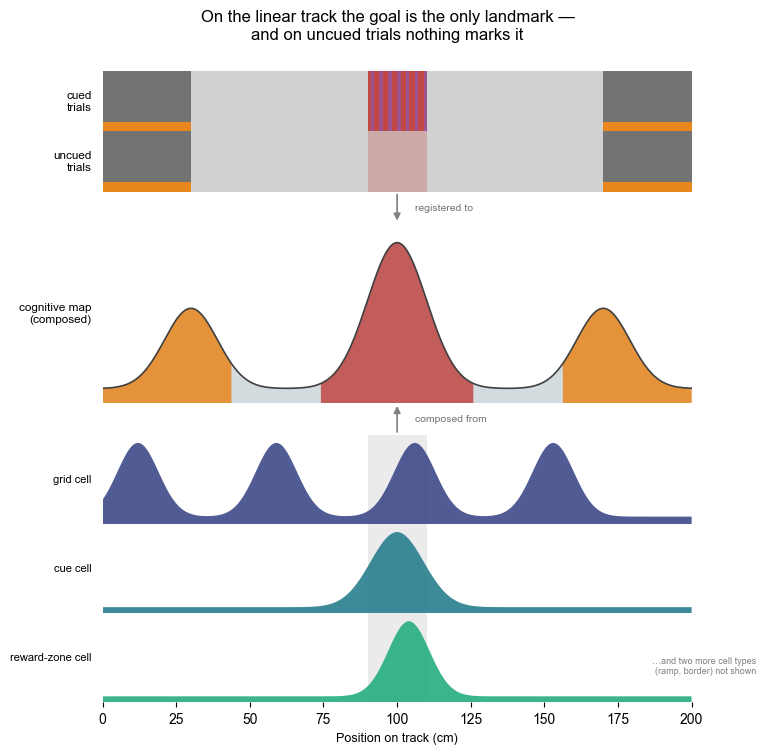

In [2]:
"""1D companion to the stack figure: the same argument on the virtual linear track.

Drawn as aligned panels rather than a 3D stack. In 2D the layers are planes and a
3D exploded view reads naturally; in 1D they are curves, and stacking curves in 3D
buries them behind one another. Sharing a single position axis instead makes the
thing that matters legible: which feature of the track each peak corresponds to.
"""
import sys, warnings, numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
sys.path.insert(0,'/Users/harryclark/Documents/spatial-manifolds/src')
plt.rcParams['font.family']='Arial'

TL=200.0; BOX=30.0; RZ=(90.0,110.0)
x=np.linspace(0,TL,600)
def gauss(mu,s): return np.exp(-0.5*((x-mu)/s)**2)
C_GOAL,C_BOUND,C_CUE='#c04744','#e8871e','#9d5391'
vir=plt.get_cmap('viridis')

LAYERS=[('grid cell',      0.10+sum(gauss(p,7) for p in np.arange(12,TL,47))),
        ('cue cell',       0.08+gauss(100,9)),
        ('reward-zone cell',0.08+gauss(104,7)),
        ('ramp cell',      0.06+0.95*np.clip((x-BOX)/(RZ[0]-BOX),0,1)),
        ('border cell',    0.06+gauss(BOX,7)+gauss(TL-BOX,7))]

fig=plt.figure(figsize=(7.6,8.2))
gs=fig.add_gridspec(8,1,height_ratios=[.42,.42,.22,1.25,.22]+[.62]*3,hspace=.0)

def track(ax,cued,label):
    ax.add_patch(Rectangle((0,0),TL,1,color='0.82',lw=0))
    for x0 in (0,TL-BOX):
        ax.add_patch(Rectangle((x0,0),BOX,1,color='0.45',lw=0))
        ax.add_patch(Rectangle((x0,0),BOX,.16,color=C_BOUND,lw=0))
    ax.add_patch(Rectangle((RZ[0],0),RZ[1]-RZ[0],1,color=C_GOAL,alpha=1 if cued else .28,lw=0))
    if cued:
        for xx in np.arange(RZ[0]+1,RZ[1],3.0):
            ax.add_patch(Rectangle((xx,0),1.2,1,color=C_CUE,lw=0))
    ax.set_xlim(0,TL); ax.set_ylim(0,1); ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
    ax.set_ylabel(label,rotation=0,ha='right',va='center',fontsize=8.5,labelpad=8)

track(fig.add_subplot(gs[0]),True ,'cued\ntrials')
track(fig.add_subplot(gs[1]),False,'uncued\ntrials')
ax=fig.add_subplot(gs[2]); ax.axis('off')
ax.annotate('',xy=(.5,0),xytext=(.5,1),xycoords='axes fraction',
            arrowprops=dict(arrowstyle='-|>',color='0.5',lw=1.2))
ax.text(.53,.5,'registered to',fontsize=7.5,color='0.45',transform=ax.transAxes,va='center')

# composed map: one curve, coloured by which feature each part of it represents
ax=fig.add_subplot(gs[3])
m=0.10+gauss(100,10)+0.55*gauss(BOX,9)+0.55*gauss(TL-BOX,9); m/=m.max()
ax.plot(x,m,color='0.25',lw=1.2,zorder=4)
for lo,hi,c in ((0,BOX+14,C_BOUND),(RZ[0]-16,RZ[1]+16,C_GOAL),(TL-BOX-14,TL,C_BOUND)):
    s_=(x>=lo)&(x<=hi)
    ax.fill_between(x[s_],0,m[s_],color=c,alpha=.85,linewidth=0,edgecolor='none',zorder=3)
ax.fill_between(x,0,m,color='#cfd8dc',alpha=.9,linewidth=0,edgecolor='none',zorder=2)
ax.set_xlim(0,TL); ax.set_ylim(0,1.12); ax.set_xticks([]); ax.set_yticks([])
ax.spines['bottom'].set_visible(False)
ax.set_ylabel('cognitive map\n(composed)',rotation=0,ha='right',va='center',fontsize=8.5,labelpad=8)
ax.spines[['top','right','left']].set_visible(False)

ax=fig.add_subplot(gs[4]); ax.axis('off')
ax.annotate('',xy=(.5,1),xytext=(.5,0),xycoords='axes fraction',
            arrowprops=dict(arrowstyle='-|>',color='0.5',lw=1.2))
ax.text(.53,.5,'composed from',fontsize=7.5,color='0.45',transform=ax.transAxes,va='center')

for i,(name,prof) in enumerate(LAYERS[:3]):
    ax=fig.add_subplot(gs[5+i])
    p=prof/prof.max()
    ax.fill_between(x,0,p,color=vir(0.22+0.6*i/3),alpha=.9,linewidth=0,edgecolor='none')
    ax.axvspan(*RZ,color='0.85',alpha=.5,lw=0,zorder=0)
    ax.set_xlim(0,TL); ax.set_ylim(0,1.1); ax.set_yticks([])
    ax.set_ylabel(name,rotation=0,ha='right',va='center',fontsize=8,labelpad=8)
    ax.spines[['top','right','left','bottom']].set_visible(False)
    if i<2: ax.set_xticks([])
    else: ax.set_xlabel('Position on track (cm)',fontsize=9)
fig.text(.985,.145,'…and two more cell types\n(ramp, border) not shown',
         fontsize=6.5,color='0.5',ha='right')
fig.suptitle('On the linear track the goal is the only landmark —\n'
             'and on uncued trials nothing marks it',fontsize=12,y=.955)
p='/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/fig1B_stack_1D.pdf'
plt.savefig(p,dpi=200,bbox_inches='tight'); print('saved',p)


## 1B alternative — linear track on a single flat axes

The panel version above is already pure 2-D (subplots, no 3-D projection); only the
arena figure uses `projection='3d'`. This is a different 2-D layout rather than a fix:
offset traces on one axes, which fits all five cell types and makes the read from a
peak down to the track feature a single vertical line.


saved /Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/fig1B_track_flat.pdf


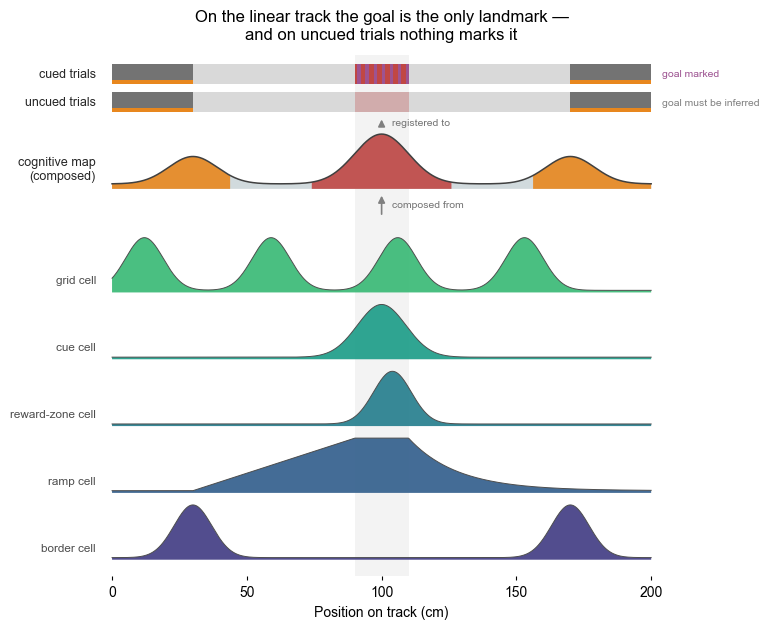

In [3]:
"""1B alternative — the linear track as a single flat axes.

Same content as the panel version, drawn as offset traces on one set of axes
instead of stacked subplots. No 3D projection anywhere: every element is a 2-D
patch or line, positioned by an explicit vertical offset. This keeps all five
cell types visible without the subplot machinery, and makes the vertical
correspondence between a peak and a track feature a straight read down the page.
"""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
plt.rcParams['font.family'] = 'Arial'

TL, BOX, RZ = 200.0, 30.0, (90.0, 110.0)
x = np.linspace(0, TL, 800)
def gauss(mu, s): return np.exp(-0.5 * ((x - mu) / s) ** 2)
C_GOAL, C_BOUND, C_CUE = '#c04744', '#e8871e', '#9d5391'
vir = plt.get_cmap('viridis')

CELLS = [('border cell',     0.04 + gauss(BOX, 7) + gauss(TL - BOX, 7)),
         ('ramp cell',       0.04 + 0.95 * np.clip((x - BOX) / (RZ[0] - BOX), 0, 1)
                             * np.where(x > RZ[1], np.exp(-(x - RZ[1]) / 18.0), 1.0)),
         ('reward-zone cell',0.04 + gauss(104, 7)),
         ('cue cell',        0.04 + gauss(100, 9)),
         ('grid cell',       0.04 + sum(gauss(p, 7) for p in np.arange(12, TL, 47)))]

fig, ax = plt.subplots(figsize=(7.8, 6.4))
STEP, H = 1.0, 0.82        # vertical spacing between traces, and trace height

def trace(y0, prof, color, label, alpha=.92):
    p = prof / prof.max() * H
    ax.fill_between(x, y0, y0 + p, color=color, alpha=alpha, linewidth=0, edgecolor='none')
    ax.plot(x, y0 + p, color='0.3', lw=.7)
    ax.text(-6, y0 + .18, label, ha='right', va='center', fontsize=8.5, color='0.3')

for i, (name, prof) in enumerate(CELLS):
    trace(i * STEP, prof, vir(0.18 + 0.62 * i / len(CELLS)), name)

# the composed map, coloured by which feature each part of it represents
YMAP = len(CELLS) * STEP + 0.55
m = 0.10 + gauss(100, 10) + 0.55 * gauss(BOX, 9) + 0.55 * gauss(TL - BOX, 9)
m = m / m.max() * H
ax.fill_between(x, YMAP, YMAP + m, color='#cfd8dc', alpha=.95, linewidth=0, edgecolor='none')
for lo, hi, c in ((0, BOX + 14, C_BOUND), (RZ[0] - 16, RZ[1] + 16, C_GOAL),
                  (TL - BOX - 14, TL, C_BOUND)):
    s_ = (x >= lo) & (x <= hi)
    ax.fill_between(x[s_], YMAP, YMAP + m[s_], color=c, alpha=.9, linewidth=0, edgecolor='none')
ax.plot(x, YMAP + m, color='0.25', lw=1.1)
ax.text(-6, YMAP + .3, 'cognitive map\n(composed)', ha='right', va='center',
        fontsize=9, color='0.15')

# the track itself, cued and uncued
for k, (lab, cued) in enumerate((('uncued trials', False), ('cued trials', True))):
    Y = YMAP + 1.15 + k * 0.42
    ax.add_patch(Rectangle((0, Y), TL, .3, color='0.85', lw=0))
    for x0 in (0, TL - BOX):
        ax.add_patch(Rectangle((x0, Y), BOX, .3, color='0.45', lw=0))
        ax.add_patch(Rectangle((x0, Y), BOX, .06, color=C_BOUND, lw=0))
    ax.add_patch(Rectangle((RZ[0], Y), RZ[1] - RZ[0], .3,
                           color=C_GOAL, alpha=1 if cued else .3, lw=0))
    if cued:
        for xx in np.arange(RZ[0] + 1, RZ[1], 3.0):
            ax.add_patch(Rectangle((xx, Y), 1.2, .3, color=C_CUE, lw=0))
    ax.text(-6, Y + .15, lab, ha='right', va='center', fontsize=9, color='0.15')
    ax.text(TL + 4, Y + .15, 'goal marked' if cued else 'goal must be inferred',
            fontsize=7.5, color=C_CUE if cued else '0.5', va='center')

ax.annotate('', xy=(TL * .5, YMAP - .06), xytext=(TL * .5, YMAP - .42),
            arrowprops=dict(arrowstyle='-|>', color='0.5', lw=1.2))
ax.text(TL * .5 + 4, YMAP - .24, 'composed from', fontsize=7.5, color='0.45', va='center')
ax.annotate('', xy=(TL * .5, YMAP + 1.08), xytext=(TL * .5, YMAP + H + .1),
            arrowprops=dict(arrowstyle='-|>', color='0.5', lw=1.2))
ax.text(TL * .5 + 4, YMAP + 1.0, 'registered to', fontsize=7.5, color='0.45', va='center')

ax.axvspan(RZ[0], RZ[1], color='0.9', alpha=.45, zorder=0, lw=0)
ax.set_xlim(-4, TL + 4); ax.set_ylim(-.25, YMAP + 2.0)
ax.set_yticks([]); ax.set_xlabel('Position on track (cm)', fontsize=10)
ax.set_xticks([0, 50, 100, 150, 200])
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(axis='x', length=3)
ax.set_title('On the linear track the goal is the only landmark —\n'
             'and on uncued trials nothing marks it', fontsize=12, pad=12)
plt.tight_layout()
_p = ('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
      'AnchorDynamics2026/fig1B_track_flat.pdf')
plt.savefig(_p, dpi=200, bbox_inches='tight'); print('saved', _p)


## 1C — example session (M26 D18)

Real data, not a schematic: stopping behaviour on each trial type beside the
per-trial population anchoring state. The loaders, stop raster and anchoring
classifier are exec'd out of `lick_raster_by_trial_type.ipynb` rather than
reimplemented here, so this panel cannot drift from the analysis it illustrates.
Only the layout is defined below — shorter than the catalogue render (10x4.6 to
10x2.9), since 318 trials on the y axis gain nothing from the extra height.


setup ready
plotting helpers ready
anchoring helper ready
M26 D18: 87 cells x 318 trials, PC1 0.338, 1842 stops
saved /Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/fig1C_example_session_M26D18.pdf


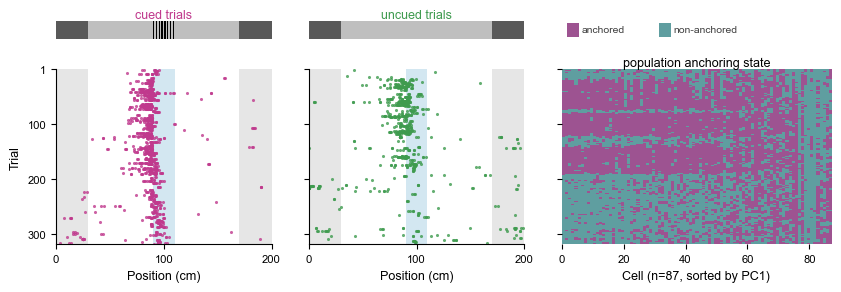

In [4]:
"""1C — example session: stopping behaviour and population anchoring (M26 D18).

Loaded rather than re-implemented: the VR loaders, the stop raster and the
population anchoring classifier all live in `lick_raster_by_trial_type.ipynb`,
and are exec'd from there so this figure cannot drift from the analysis it
illustrates. The only thing defined here is the layout.

Shorter than the catalogue version (10x4.6 -> 10x2.9): the trial axis carries
318 trials, so vertical space buys no resolution, and Figure 1 needs the row.
"""
import json, os, sys, warnings
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')
import matplotlib; import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')

_NB = ('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
       'AnchorDynamics2026/lick_raster_by_trial_type.ipynb')
_g = {}
for _c in json.load(open(_NB))['cells']:
    if _c['cell_type'] != 'code':
        continue
    _s = ''.join(_c['source'])
    if _s.startswith('MOUSE, DAY') or 'INV = pd.DataFrame' in _s:
        continue                      # skip the example-figure and inventory cells
    exec(compile(_s, '<lick_nb>', 'exec'), _g)
globals().update({k: v for k, v in _g.items() if not k.startswith('__')})

MOUSE, DAY = 26, 18
beh, trials, stops = load_vr(MOUSE, DAY)
trials_a, L, frac = population_anchoring(MOUSE, DAY)

Lc = np.nan_to_num(L - np.nanmean(L, axis=1, keepdims=True))
# Orient PC1 by its correlation with the population anchored fraction. The
# loadings come from MEAN-CENTRED data, so their sign says which way a cell moves
# with the component and nothing about its baseline rate; an earlier version
# compared the top-loading cells' anchored fraction against the population mean,
# which is a different quantity and flipped the sign whenever those cells happened
# to sit below average (here 0.486 vs 0.543, giving corr = -0.991 instead of
# +0.991 -- an inverted colour scale and a reversed cell ordering).
U, sv, Vt = np.linalg.svd(Lc, full_matrices=False)
load, pc1_score = U[:, 0], Vt[0]
if np.corrcoef(pc1_score, np.nan_to_num(frac))[0, 1] < 0:
    load, pc1_score = -load, -pc1_score
order = np.argsort(load)[::-1]
pc1 = float(sv[0] ** 2 / np.sum(sv ** 2))
T0, NT = 1, int(trials.number.max())
print(f'M{MOUSE} D{DAY}: {L.shape[0]} cells x {L.shape[1]} trials, PC1 {pc1:.3f}, '
      f'{len(stops)} stops')

TA_CMAP = ListedColormap([NONANCH_COLOR, ANCH_COLOR])
TA_NORM = BoundaryNorm([-0.5, 0.5, 1.5], TA_CMAP.N)

fig = plt.figure(figsize=(10, 2.9))
gs = fig.add_gridspec(2, 3, height_ratios=[.10, 1], width_ratios=[1, 1, 1.25],
                      hspace=.32, wspace=.16)
axes = []
for j, (tt, col, name, cued) in enumerate([('b', CUED_C, 'cued', True),
                                           ('nb', UNCUED_C, 'uncued', False)]):
    # the type label goes on the track strip, not on the raster, or it lands
    # underneath the strip once the panel is this short
    axs = fig.add_subplot(gs[0, j])
    track_schematic(axs, cued)
    axs.set_title(f'{name} trials', fontsize=9, color=col, pad=2)
    ax = fig.add_subplot(gs[1, j], sharey=axes[0] if axes else None)
    stop_raster(ax, stops, trials, tt, col, '', T0, NT)
    ax.set_xlabel('Position (cm)', fontsize=9)
    ax.set_xticks([0, 100, 200])
    ax.tick_params(labelsize=8)
    if j == 0:
        ax.set_ylabel('Trial', fontsize=9)
        ax.set_yticks([1, 100, 200, 300])
    else:
        ax.tick_params(labelleft=False)
    axes.append(ax)

ax = fig.add_subplot(gs[1, 2], sharey=axes[0])
ax.imshow(L[order].T, aspect='auto', cmap=TA_CMAP, norm=TA_NORM,
          interpolation='nearest', extent=[0, L.shape[0], NT, T0])
ax.set_xlabel(f'Cell (n={L.shape[0]}, sorted by PC1)', fontsize=9)
ax.tick_params(labelleft=False, labelsize=8)
ax.set_title('population anchoring state', fontsize=9, pad=2)
for sp in ax.spines.values():
    sp.set_visible(False)
# legend sits in the margin above the map, not over it: every pixel of the map
# is data, and the stats block the catalogue put here belongs in the caption
axl = fig.add_subplot(gs[0, 2]); axl.axis('off')
for k, (lab, c) in enumerate((('anchored', ANCH_COLOR), ('non-anchored', NONANCH_COLOR))):
    axl.add_patch(Rectangle((.02 + k * .34, .1), .045, .8, color=c, lw=0))
    axl.text(.075 + k * .34, .5, lab, fontsize=7.5, va='center', color='0.25')
axl.set_xlim(0, 1); axl.set_ylim(0, 1)

plt.tight_layout()
_p = ('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
      'AnchorDynamics2026/fig1C_example_session_M26D18.pdf')
plt.savefig(_p, dpi=200, bbox_inches='tight')
print('saved', _p)
plt.show()


## Figure 1 composite — example session, example units, behaviour by state

A 4 x 2 layout.

**Row 1** reproduces the stop-anchoring catalogue page for M26 D18: stops on
cued and uncued trials, a blank third column holding the legend, and the
per-trial population anchoring state in the fourth.

**Row 2** shows three example units as trial x position rate maps, each with a
strip of that cell's own anchoring labels down the left edge so the banding can
be read against it, and in the fourth column the hit rate on cued and uncued
trials split by population anchoring state, one point per session.

Example units are chosen as those whose own anchoring labels best agree with the
population state, since those are the cells whose rate maps show the effect the
figure is about. That is a deliberate selection and should be described as such
in the caption, not presented as typical.


setup ready
plotting helpers ready
anchoring helper ready
6 major anchoring transitions (median filter 9 trials): [np.int64(22), np.int64(76), np.int64(82), np.int64(124), np.int64(138), np.int64(192)]
M26D18: 87 cells x 318 trials, 1842 stops
example cells: [154, 153, 138] agreement [0.95 0.92 0.91] (see fig1_all_units_M26D18.pdf to choose others)
hit-rate panel: 46 sessions with >=10 trials in all four cells
ADI panel: 46 sessions with both AUCs
saved /Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/fig1_session_units_behaviour.pdf


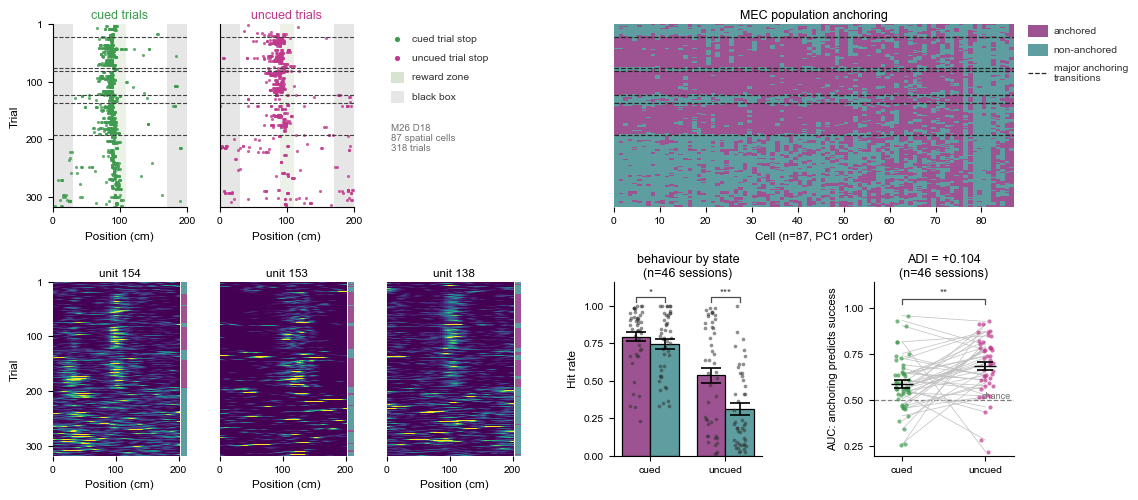


hit rate by trial type and population state:
  cued_A     0.796 +- 0.199
  cued_N     0.745 +- 0.210
  uncued_A   0.538 +- 0.347
  uncued_N   0.310 +- 0.261
  cued: anchored - non-anchored = +0.051, p=0.0103, higher in 27/46
  uncued: anchored - non-anchored = +0.227, p=1.27e-11, higher in 42/46

ADI: AUC cued 0.564, uncued 0.699, ADI +0.104, p=0.00101, >0 in 30/46


In [5]:
"""Figure 1 composite: example session, example units, and behaviour by state.

Row 1  stops on cued and uncued trials, a blank column for the legend, and the
       per-trial population anchoring state -- the same content as the
       stop-anchoring catalogue page for this session.
Row 2  three example units as trial x position rate maps, and the hit rate on
       cued and uncued trials split by population anchoring state, one point
       per session.

Analysis code is exec'd out of lick_raster_by_trial_type.ipynb rather than
reimplemented, so the panel cannot drift from the analysis it illustrates.
"""
import json, os, sys, warnings
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle
import pynapple as nap
from scipy.stats import wilcoxon
from sklearn.metrics import roc_auc_score
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')

_NB = ('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
       'AnchorDynamics2026/lick_raster_by_trial_type.ipynb')
_g = {}
for _c in json.load(open(_NB))['cells']:
    if _c['cell_type'] != 'code':
        continue
    _s = ''.join(_c['source'])
    if _s.startswith('MOUSE, DAY') or 'INV = pd.DataFrame' in _s:
        continue
    exec(compile(_s, '<lick_nb>', 'exec'), _g)
globals().update({k: v for k, v in _g.items() if not k.startswith('__')})
from spatial_manifolds.anchoring import trial_cluster_labels, smooth_nanaware

FIG = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026'
MOUSE, DAY = 26, 18
SIGMA = 2.0          # rate-map smoothing, position bins (4 cm)
EXAMPLES = None              # e.g. [154, 109, 139]; None picks by agreement
RZ_COLOR = '#d8e4d0'         # reward-zone shading
# cued/uncued swapped relative to the shared constants in
# lick_raster_by_trial_type.ipynb, which every other figure still uses
CUED_C, UNCUED_C = UNCUED_C, CUED_C
TA_CMAP = ListedColormap([NONANCH_COLOR, ANCH_COLOR])
TA_NORM = BoundaryNorm([-0.5, 0.5, 1.5], TA_CMAP.N)


def smooth_map(M, sigma=SIGMA):
    """NaN-aware smoothing along POSITION only, per trial.

    Never across trials: the trial axis is where the anchoring banding lives, and
    smoothing it would manufacture the structure the figure is meant to show.
    """
    return np.array([smooth_nanaware(r, sigma=sigma) for r in M])


def session_ratemaps(mouse, day):
    """Per-cell trial x position rate maps and anchoring labels, clipped."""
    bp, cp = vr_paths(mouse, day)
    beh = nap.load_file(bp); clusters = nap.load_file(cp)
    trials_all = beh['trials'].as_dataframe()
    trials, orig = clip_trials(trials_all, clusters)
    keep = np.isin(trials_all.number.values.astype(int), orig)
    tn, trav = beh['trial_number'], beh['travel']
    dt = trav - (float(np.asarray(tn.values)[0]) - 1) * TL
    moving = beh['S'].threshold(3.0, method='above').time_support
    n_tr = len(trials_all)
    ids = spatial_cell_ids(mouse, day, clusters)   # MEC only
    tc = nap.compute_1d_tuning_curves(clusters[ids], dt, nb_bins=n_tr * NBIN,
                                      minmax=[0, n_tr * TL], ep=moving)
    maps, labs, kept = [], [], []
    for c in ids:
        M = np.asarray(tc[c]).reshape(n_tr, NBIN)[keep]
        lab, _, _, _ = trial_cluster_labels(M)
        if np.isnan(lab).all():
            continue
        maps.append(M); labs.append(lab); kept.append(c)
    return trials, np.array(maps), np.array(labs), np.array(kept)


# ---------------------------------------------------------------- data
beh, trials, stops = load_vr(MOUSE, DAY)
_, MAPS, L, CIDS = session_ratemaps(MOUSE, DAY)
frac = np.nanmean(L, axis=0)
Lc = np.nan_to_num(L - np.nanmean(L, axis=1, keepdims=True))
# Orient PC1 by its correlation with the population anchored fraction. The
# loadings come from MEAN-CENTRED data, so their sign says which way a cell moves
# with the component and nothing about its baseline rate; an earlier version
# compared the top-loading cells' anchored fraction against the population mean,
# which is a different quantity and flipped the sign whenever those cells happened
# to sit below average (here 0.486 vs 0.543, giving corr = -0.991 instead of
# +0.991 -- an inverted colour scale and a reversed cell ordering).
U, sv, Vt = np.linalg.svd(Lc, full_matrices=False)
load, pc1_score = U[:, 0], Vt[0]
if np.corrcoef(pc1_score, np.nan_to_num(frac))[0, 1] < 0:
    load, pc1_score = -load, -pc1_score
order = np.argsort(load)[::-1]
T0, NT = 1, int(trials.number.max())

# Major anchoring transitions: changes in the population state after a median
# filter removes short flickers. Marking every raw state change would cover the
# rasters in lines -- this session has 11 runs, half of them under 9 trials. An
# earlier version instead required both neighbouring runs to exceed a length,
# which silently drops a boundary whenever a long block is interrupted by a brief
# one, so clear block edges went unmarked. Filtering first keeps the block
# structure intact.
from scipy.ndimage import median_filter
MAJOR_FILT = 9                      # trials; must be odd
_st = median_filter((frac > 0.5).astype(float), size=MAJOR_FILT,
                    mode='nearest') > 0.5
_bounds = list(np.where(np.diff(_st.astype(int)) != 0)[0] + 1)
TRANSITIONS = [T0 + b for b in _bounds]
print(f'{len(TRANSITIONS)} major anchoring transitions '
      f'(median filter {MAJOR_FILT} trials): {TRANSITIONS}')
print(f'M{MOUSE}D{DAY}: {L.shape[0]} cells x {L.shape[1]} trials, {len(stops)} stops')

# examples: cells whose own anchoring best matches the population state, since
# those are the ones whose rate maps show the effect the figure is about
agree = np.array([np.nanmean((l > .5) == (frac > .5)) for l in L])
if EXAMPLES is not None:
    missing = [u for u in EXAMPLES if u not in set(CIDS)]
    if missing:
        raise ValueError(
            f'units {missing} are not in the anchoring population for '
            f'M{MOUSE}D{DAY}. With REGION_PREFIX={"ENTm"!r} only MEC cells are '
            f'included -- 202 and 192, for instance, are in VISpl5. Pick from '
            f'fig1_all_units_M{MOUSE}D{DAY}.csv.')
    EX = [int(np.where(CIDS == u)[0][0]) for u in EXAMPLES]
else:
    cand = np.argsort(agree)[::-1]
    EX = [c for c in cand if np.nanmean(MAPS[c]) > 0.5][:3]
print('example cells:', [int(CIDS[c]) for c in EX],
      'agreement', np.round(agree[EX], 2),
      '(see fig1_all_units_M26D18.pdf to choose others)')

# ---------------------------------------------------------------- hit rates
# Canonical trial table: behaviour joined to the anchoring state over every
# session that has cached labels. Built on demand if it is not already there, so
# this cell runs from nothing but the labels -- Figure 1 previously read
# eye_anchoring_trials.csv, which silently restricted these panels to the 58
# sessions with eye tracking, a constraint with no scientific content here.
import sys as _sys
_FIGDIR = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026'
if _FIGDIR not in _sys.path:
    _sys.path.insert(0, _FIGDIR)
from build_trial_table import ensure_trial_table
H = ensure_trial_table()
H['anch'] = H.frac_anch > 0.5
H['hit'] = (H.perf == 'hit').astype(float)
MIN_N = 10
rows = []
for (mo, dy), g in H.groupby(['mouse', 'day']):
    r = dict(mouse=mo, day=dy)
    ok = True
    for tt, tn_ in (('b', 'cued'), ('nb', 'uncued')):
        for st, sn in ((True, 'A'), (False, 'N')):
            m = (g.ttype == tt) & (g.anch == st)
            if m.sum() < MIN_N:
                ok = False
            r[f'{tn_}_{sn}'] = g.hit[m].mean() if m.sum() >= MIN_N else np.nan
    # ADI: how much better does the anchoring state predict success when the
    # goal is NOT cued? AUC is used rather than correlation because the two trial
    # types have very different base rates, and AUC is invariant to prevalence.
    for tt, tn_ in (('b', 'cued'), ('nb', 'uncued')):
        m = g.ttype == tt
        y = g.hit[m].values
        x = g.frac_anch[m].values
        v = np.isfinite(x) & np.isfinite(y)
        r[f'auc_{tn_}'] = (roc_auc_score(y[v], x[v])
                           if v.sum() >= 25 and 0 < y[v].mean() < 1 else np.nan)
    if ok:
        rows.append(r)
HR = pd.DataFrame(rows)
HR['ADI'] = HR.auc_uncued - HR.auc_cued
print(f'hit-rate panel: {len(HR)} sessions with >={MIN_N} trials in all four cells')
print(f'ADI panel: {int(HR.ADI.notna().sum())} sessions with both AUCs')

# ---------------------------------------------------------------- figure
# Two empty spacer columns, sized independently: column 3 keeps the hit-rate
# panel clear of the last rate map (its y label needs the room), and the wider
# column 5 separates the two quantitative panels. A single global wspace cannot
# do this -- it moves every gap at once.
fig = plt.figure(figsize=(12.4, 5.6))          # fits A4 landscape
gs = fig.add_gridspec(2, 7, width_ratios=[.98, .98, .98, .20, 1.08, .34, 1.02],
                      height_ratios=[1, 0.95], hspace=.42, wspace=.30)

# --- row 1: stop rasters -----------------------------------------------------
axes = []
for j, (tt, col, name, cued) in enumerate([('b', CUED_C, 'cued', True),
                                           ('nb', UNCUED_C, 'uncued', False)]):
    ax = fig.add_subplot(gs[0, j], sharey=axes[0] if axes else None)
    stop_raster(ax, stops, trials, tt, col, '', T0, NT)
    for pt in ax.patches:                       # stop_raster hardcodes the RZ colour
        if matplotlib.colors.to_hex(pt.get_facecolor()) == '#9ecae1':
            pt.set_color(RZ_COLOR)
    for tb in TRANSITIONS:
        ax.axhline(tb, color='0.25', lw=.8, ls='--', zorder=4)
    ax.set_title(f'{name} trials', fontsize=9, color=col, pad=4)
    ax.set_xlabel('Position (cm)', fontsize=8.5)
    ax.set_xticks([0, 100, 200]); ax.tick_params(labelsize=7.5)
    if j == 0:
        ax.set_ylabel('Trial', fontsize=8.5); ax.set_yticks([1, 100, 200, 300])
    else:
        ax.tick_params(labelleft=False, left=False)
    axes.append(ax)

# --- row 1 col 3: legend -----------------------------------------------------
axl = fig.add_subplot(gs[0, 2]); axl.axis('off')
axl.set_xlim(0, 1); axl.set_ylim(0, 1)
y = .92
for lab, c, kind in (('cued trial stop', CUED_C, 'dot'),
                     ('uncued trial stop', UNCUED_C, 'dot'),
                     ('reward zone', RZ_COLOR, 'box'),
                     ('black box', '0.9', 'box')):
    if kind == 'dot':
        axl.scatter([.08], [y], s=14, color=c, linewidths=0)
    else:
        axl.add_patch(Rectangle((.03, y - .032), .10, .064, color=c, lw=0))
    axl.text(.19, y, lab, fontsize=7.5, va='center', color='0.2')
    y -= .105
axl.text(.03, y - .04, f'M{MOUSE} D{DAY}\n{L.shape[0]} spatial cells\n{NT} trials',
         fontsize=7, va='top', color='0.45')

# --- row 1 col 4: population anchoring --------------------------------------
ax = fig.add_subplot(gs[0, 4:], sharey=axes[0])
ax.imshow(L[order].T, aspect='auto', cmap=TA_CMAP, norm=TA_NORM,
          interpolation='nearest', extent=[0, L.shape[0], NT, T0])
for tb in TRANSITIONS:
    ax.axhline(tb, color='0.15', lw=.9, ls='--', zorder=4)
ax.set_xlabel(f'Cell (n={L.shape[0]}, PC1 order)', fontsize=8.5)
ax.set_title('MEC population anchoring', fontsize=9, pad=4)
ax.tick_params(labelleft=False, left=False, labelsize=7.5)
for sp in ax.spines.values():
    sp.set_visible(False)
# state legend sits to the RIGHT of the raster, beside the thing it labels
for kk, (lab, cc) in enumerate((('anchored', ANCH_COLOR),
                                ('non-anchored', NONANCH_COLOR))):
    ax.add_patch(Rectangle((1.035, .93 - kk * .10), .05, .065, color=cc, lw=0,
                           transform=ax.transAxes, clip_on=False))
    ax.text(1.10, .962 - kk * .10, lab, transform=ax.transAxes, fontsize=7.5,
            va='center', color='0.2')
ax.plot([1.035, 1.085], [.735, .735], transform=ax.transAxes, color='0.15',
        lw=.9, ls='--', clip_on=False)
ax.text(1.10, .735, 'major anchoring\ntransitions', transform=ax.transAxes,
        fontsize=7.5, va='center', color='0.2')

# --- row 2 cols 1-3: example units ------------------------------------------
for k, ci in enumerate(EX):
    ax = fig.add_subplot(gs[1, k])
    M = smooth_map(MAPS[ci])
    vmax = np.nanpercentile(M, 99)
    ax.imshow(M, aspect='auto', cmap='viridis', vmin=0, vmax=vmax,
              interpolation='nearest', extent=[0, TL, NT, T0])
    # state strip on the RIGHT edge, so the banding can be read against it
    for t in range(L.shape[1]):
        ax.add_patch(Rectangle((TL + 4, T0 + t), 9, 1, clip_on=False, lw=0,
                               color=ANCH_COLOR if L[ci, t] > .5 else NONANCH_COLOR))
    ax.set_xlim(0, TL + 13)
    ax.set_title(f'unit {int(CIDS[ci])}', fontsize=8.5, pad=4)
    ax.set_xlabel('Position (cm)', fontsize=8.5)
    ax.set_xticks([0, 100, 200]); ax.tick_params(labelsize=7.5)
    if k == 0:
        ax.set_ylabel('Trial', fontsize=8.5); ax.set_yticks([1, 100, 200, 300])
    else:
        ax.set_yticks([])          # labelleft=False alone leaves the tick marks
    for sp in ax.spines.values():
        sp.set_visible(False)

# --- row 2 col 4: hit rate by trial type and state --------------------------
ax = fig.add_subplot(gs[1, 4])
keys = ['cued_A', 'cued_N', 'uncued_A', 'uncued_N']
cols = [ANCH_COLOR, NONANCH_COLOR, ANCH_COLOR, NONANCH_COLOR]
xs = [0, 0.80, 2.1, 2.90]
rng = np.random.default_rng(0)
for x, k, c in zip(xs, keys, cols):
    v = HR[k].dropna().values
    sem = v.std(ddof=1) / np.sqrt(len(v))
    ax.bar(x, v.mean(), width=.80, color=c, lw=.9, edgecolor='k', zorder=1)
    ax.errorbar(x, v.mean(), yerr=sem, color='k', lw=1.2, capsize=7,
                capthick=1.2, zorder=5)
    ax.scatter(x + rng.uniform(-.17, .17, len(v)), v, s=7, color='0.2',
               alpha=.55, zorder=3, linewidths=0)
for x0, x1, k0, k1 in ((0, 0.80, 'cued_A', 'cued_N'), (2.1, 2.90, 'uncued_A', 'uncued_N')):
    a, b = HR[k0].values, HR[k1].values
    m = np.isfinite(a) & np.isfinite(b)
    p = wilcoxon(a[m], b[m])[1]
    yy = 1.03
    ax.plot([x0, x0, x1, x1], [yy, yy + .03, yy + .03, yy], color='0.3', lw=.9)
    star = 'n.s.' if p > .05 else ('*' if p > .01 else ('**' if p > .001 else '***'))
    ax.text((x0 + x1) / 2, yy + .045, star, ha='center', fontsize=7.5, color='0.2')
ax.set_xlim(-.62, 3.52)
ax.set_xticks([(xs[0] + xs[1]) / 2, (xs[2] + xs[3]) / 2])
ax.set_xticklabels(['cued', 'uncued'], fontsize=8.5)
ax.set_ylabel('Hit rate', fontsize=8.5)
ax.set_ylim(0, 1.16); ax.set_yticks([0, .25, .5, .75, 1])
ax.tick_params(labelsize=7.5)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title(f'behaviour by state\n(n={len(HR)} sessions)', fontsize=9, pad=4)

# --- row 2 col 5: anchoring dependence index --------------------------------
ax = fig.add_subplot(gs[1, 6])
A = HR.dropna(subset=['auc_cued', 'auc_uncued'])
for _, r in A.iterrows():
    ax.plot([0, 1], [r.auc_cued, r.auc_uncued], color='0.75', lw=.5, zorder=1)
for x, k, c in ((0, 'auc_cued', CUED_C), (1, 'auc_uncued', UNCUED_C)):
    v = A[k].values
    ax.scatter(np.full(len(v), x) + rng.uniform(-.09, .09, len(v)), v, s=9,
               color=c, alpha=.7, zorder=3, linewidths=0)
    ax.errorbar(x, v.mean(), yerr=v.std(ddof=1) / np.sqrt(len(v)), color='k',
                lw=1.3, capsize=6, capthick=1.2, marker='_', ms=16, zorder=4)
ax.axhline(.5, color='0.5', ls='--', lw=.9, zorder=0)
ax.text(1.31, .5, 'chance', fontsize=6.5, color='0.45', ha='right', va='bottom')
p_adi = wilcoxon(A.ADI)[1]
star = 'n.s.' if p_adi > .05 else ('*' if p_adi > .01 else ('**' if p_adi > .001 else '***'))
ax.plot([0, 0, 1, 1], [1.02, 1.05, 1.05, 1.02], color='0.3', lw=.9)
ax.text(.5, 1.07, star, ha='center', fontsize=7.5, color='0.2')
ax.set_xlim(-.34, 1.34); ax.set_ylim(.2, 1.14)
ax.set_xticks([0, 1]); ax.set_xticklabels(['cued', 'uncued'], fontsize=8.5)
ax.set_ylabel('AUC: anchoring predicts success', fontsize=8)
ax.set_yticks([.25, .5, .75, 1]); ax.tick_params(labelsize=7.5)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title(f'ADI = {A.ADI.median():+.3f}\n(n={len(A)} sessions)', fontsize=9, pad=4)

out = f'{FIG}/fig1_session_units_behaviour.pdf'
plt.savefig(out, dpi=200, bbox_inches='tight')
print('saved', out)
plt.show()

print('\nhit rate by trial type and population state:')
for k in keys:
    print(f'  {k:10s} {HR[k].mean():.3f} +- {HR[k].std():.3f}')
for k0, k1, nm in (('cued_A', 'cued_N', 'cued'), ('uncued_A', 'uncued_N', 'uncued')):
    a, b = HR[k0].values, HR[k1].values
    m = np.isfinite(a) & np.isfinite(b)
    print(f'  {nm}: anchored - non-anchored = {np.mean(a[m]-b[m]):+.3f}, '
          f'p={wilcoxon(a[m],b[m])[1]:.3g}, higher in {int((a[m]>b[m]).sum())}/{m.sum()}')
print(f'\nADI: AUC cued {A.auc_cued.median():.3f}, uncued {A.auc_uncued.median():.3f}, '
      f'ADI {A.ADI.median():+.3f}, p={p_adi:.3g}, >0 in {int((A.ADI>0).sum())}/{len(A)}')


## All units in the example session — for choosing which to show

Every spatial unit in M26 D18 as a trial x position rate map, with that cell's
own anchoring labels as a strip down the left edge, ordered by how closely its
anchoring tracks the population state. The whole population is shown, including
the cells that do not follow it, so the choice is made against the full picture
rather than a pre-filtered one.

Writes a multi-page PDF and a CSV of unit id, class, agreement, mean rate and
anchored fraction. To use different examples, set `EXAMPLES = [154, 138, 153]`
in the composite cell above to whichever ids you pick.

Rate maps here and in the composite are smoothed along **position only**
(NaN-aware, sigma 2 bins = 4 cm). Smoothing across trials is deliberately not
done: the trial axis is where the anchoring banding lives, and blurring it
would manufacture the structure the figure exists to show.


In [6]:
"""Contact sheet of every spatial unit in M26 D18, for choosing figure examples.

Each panel is one unit's trial x position rate map with its own anchoring labels
as a strip down the left edge. Units are ordered by how closely their own
anchoring tracks the population state, so the clearest candidates come first --
but the whole population is shown, including the ones that do not follow it, so
the choice is made against the full picture rather than a pre-filtered one.

Rate maps are smoothed along POSITION only (NaN-aware, sigma 2 bins = 4 cm).
Smoothing across trials is deliberately not done: the trial axis is where the
anchoring banding lives, and blurring it would manufacture the structure the
figure is meant to show.
"""
import json, os, sys, warnings
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Rectangle
import pynapple as nap
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')

_NB = ('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
       'AnchorDynamics2026/lick_raster_by_trial_type.ipynb')
_g = {}
for _c in json.load(open(_NB))['cells']:
    if _c['cell_type'] != 'code':
        continue
    _s = ''.join(_c['source'])
    if _s.startswith('MOUSE, DAY') or 'INV = pd.DataFrame' in _s:
        continue
    exec(compile(_s, '<lick_nb>', 'exec'), _g)
globals().update({k: v for k, v in _g.items() if not k.startswith('__')})
from spatial_manifolds.anchoring import trial_cluster_labels, smooth_nanaware

FIG = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026'
MOUSE, DAY = 26, 18
SIGMA = 2.0          # position bins (4 cm)
PER_PAGE = 40        # 8 x 5


def smooth_map(M, sigma=SIGMA):
    """NaN-aware smoothing along position, per trial. Never across trials."""
    return np.array([smooth_nanaware(r, sigma=sigma) for r in M])


def session_ratemaps(mouse, day):
    bp, cp = vr_paths(mouse, day)
    beh = nap.load_file(bp); clusters = nap.load_file(cp)
    trials_all = beh['trials'].as_dataframe()
    trials, orig = clip_trials(trials_all, clusters)
    keep = np.isin(trials_all.number.values.astype(int), orig)
    tn, trav = beh['trial_number'], beh['travel']
    dt = trav - (float(np.asarray(tn.values)[0]) - 1) * TL
    moving = beh['S'].threshold(3.0, method='above').time_support
    n_tr = len(trials_all)
    ids = spatial_cell_ids(mouse, day, clusters)   # MEC only
    cls = CLS[(CLS.mouse == mouse) & (CLS.day == day)]
    klass = dict(zip(cls.cluster_id.astype(int), cls.cell_class_of1))
    tc = nap.compute_1d_tuning_curves(clusters[ids], dt, nb_bins=n_tr * NBIN,
                                      minmax=[0, n_tr * TL], ep=moving)
    maps, labs, kept = [], [], []
    for c in ids:
        M = np.asarray(tc[c]).reshape(n_tr, NBIN)[keep]
        lab, _, _, _ = trial_cluster_labels(M)
        if np.isnan(lab).all():
            continue
        maps.append(M); labs.append(lab); kept.append(c)
    return trials, np.array(maps), np.array(labs), np.array(kept), klass


trials, MAPS, L, CIDS, KLASS = session_ratemaps(MOUSE, DAY)
frac = np.nanmean(L, axis=0)
NT = int(trials.number.max())
agree = np.array([np.nanmean((l > .5) == (frac > .5)) for l in L])
rate = np.array([np.nanmean(m) for m in MAPS])
order = np.argsort(-agree)
print(f'M{MOUSE}D{DAY}: {len(CIDS)} units, {L.shape[1]} trials')

pdf_path = f'{FIG}/fig1_all_units_M{MOUSE}D{DAY}.pdf'
with PdfPages(pdf_path) as pdf:
    for p0 in range(0, len(order), PER_PAGE):
        page = order[p0:p0 + PER_PAGE]
        fig, axes = plt.subplots(5, 8, figsize=(16, 11),
                                 gridspec_kw=dict(hspace=.55, wspace=.30))
        for ax, ci in zip(axes.ravel(), page):
            M = smooth_map(MAPS[ci])
            vmax = np.nanpercentile(M, 99)
            ax.imshow(M, aspect='auto', cmap='viridis', vmin=0,
                      vmax=vmax if vmax > 0 else 1, interpolation='nearest',
                      extent=[0, TL, NT, 1])
            for t in range(L.shape[1]):
                ax.add_patch(Rectangle((TL + 5, 1 + t), 13, 1, clip_on=False, lw=0,
                                       color=ANCH_COLOR if L[ci, t] > .5 else NONANCH_COLOR))
            ax.set_xlim(0, TL + 18)
            k = KLASS.get(int(CIDS[ci]), '?')
            ax.set_title(f'{int(CIDS[ci])}  {k}\nagree {agree[ci]:.2f}  '
                         f'{rate[ci]:.1f} Hz', fontsize=6.5, pad=3)
            ax.set_xticks([0, 100, 200]); ax.tick_params(labelsize=5.5)
            ax.set_yticks([1, NT])
            for sp in ax.spines.values():
                sp.set_visible(False)
        for ax in axes.ravel()[len(page):]:
            ax.axis('off')
        fig.suptitle(f'M{MOUSE} D{DAY} — all spatial units, ordered by agreement with '
                     f'the population anchoring state  (units {p0+1}–{p0+len(page)} '
                     f'of {len(order)})', fontsize=11, y=.975)
        pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)
print('saved', pdf_path)

T = pd.DataFrame(dict(unit=CIDS[order], cls=[KLASS.get(int(c), '?') for c in CIDS[order]],
                      agreement=np.round(agree[order], 3),
                      mean_rate=np.round(rate[order], 2),
                      frac_anchored=np.round([np.nanmean(L[c]) for c in order], 3)))
T.to_csv(f'{FIG}/fig1_all_units_M{MOUSE}D{DAY}.csv', index=False)
print('unit table ->', f'{FIG}/fig1_all_units_M{MOUSE}D{DAY}.csv')
print('\ntop 12 by agreement with the population state:')
print(T.head(12).to_string(index=False))


setup ready
plotting helpers ready
anchoring helper ready
M26D18: 87 units, 318 trials
saved /Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/fig1_all_units_M26D18.pdf
unit table -> /Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/fig1_all_units_M26D18.csv

top 12 by agreement with the population state:
 unit cls  agreement  mean_rate  frac_anchored
  154 NGS      0.950      10.67          0.447
  153 NGS      0.915       3.06          0.531
  138 NGS      0.912       6.02          0.459
  109  GC      0.903       5.79          0.519
   97 NGS      0.899       3.73          0.522
   71 NGS      0.899       2.54          0.403
  174 NGS      0.896      18.69          0.475
   81 NGS      0.893       3.98          0.503
  145 NGS      0.874       3.14          0.453
  123 NGS      0.871      11.53          0.582
  137 NGS      0.868      28.27          0.522
  107  GC      0.865      10.86          0.557


## Figure 1 composite — version 2

Same content, different arrangement. Row 1 is the example session at trial
resolution: stops on each trial type, the legend, then the three example units,
all sharing one trial axis. Row 2 carries the MEC population anchoring state
with its own legend and its own trial axis, then the two quantitative panels.

Built with nested gridspecs because the two rows hold different numbers of
panels, which a single flat grid cannot express without spacer columns that
fight each other.

The legend column carries a viridis scale bar for the rate maps. Note it is
labelled *per cell*: each map is scaled to its own 99th percentile, so the bar
is normalised firing rate, not a shared absolute rate across the three units.


In [7]:
"""Figure 1 composite, version 2: rate maps promoted to the top row.

Row 1  stops on cued and uncued trials, the legend (with the rate-map colour
       scale), then three example units as trial x position rate maps. All five
       panels share the trial axis.
Row 2  the MEC population anchoring state with its own legend, then the hit rate
       by trial type and state, and the anchoring dependence index.

Nested gridspecs: the two rows hold different numbers of panels, and a single
flat grid cannot express that without spacer columns that fight each other.

Analysis code is exec'd out of lick_raster_by_trial_type.ipynb rather than
reimplemented, so the panel cannot drift from the analysis it illustrates.
"""
import json, os, sys, warnings
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle
import pynapple as nap
from scipy.stats import wilcoxon
from sklearn.metrics import roc_auc_score
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')

_NB = ('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
       'AnchorDynamics2026/lick_raster_by_trial_type.ipynb')
_g = {}
for _c in json.load(open(_NB))['cells']:
    if _c['cell_type'] != 'code':
        continue
    _s = ''.join(_c['source'])
    if _s.startswith('MOUSE, DAY') or 'INV = pd.DataFrame' in _s:
        continue
    exec(compile(_s, '<lick_nb>', 'exec'), _g)
globals().update({k: v for k, v in _g.items() if not k.startswith('__')})
from spatial_manifolds.anchoring import trial_cluster_labels, smooth_nanaware

FIG = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026'
MOUSE, DAY = 26, 18
SIGMA = 2.0          # rate-map smoothing, position bins (4 cm)
EXAMPLES = None              # e.g. [154, 109, 139]; None picks by agreement
RZ_COLOR = '#d8e4d0'         # reward-zone shading
# cued/uncued swapped relative to the shared constants in
# lick_raster_by_trial_type.ipynb, which every other figure still uses
CUED_C, UNCUED_C = UNCUED_C, CUED_C
TA_CMAP = ListedColormap([NONANCH_COLOR, ANCH_COLOR])
TA_NORM = BoundaryNorm([-0.5, 0.5, 1.5], TA_CMAP.N)


def smooth_map(M, sigma=SIGMA):
    """NaN-aware smoothing along POSITION only, per trial.

    Never across trials: the trial axis is where the anchoring banding lives, and
    smoothing it would manufacture the structure the figure is meant to show.
    """
    return np.array([smooth_nanaware(r, sigma=sigma) for r in M])


def session_ratemaps(mouse, day):
    """Per-cell trial x position rate maps and anchoring labels, clipped."""
    bp, cp = vr_paths(mouse, day)
    beh = nap.load_file(bp); clusters = nap.load_file(cp)
    trials_all = beh['trials'].as_dataframe()
    trials, orig = clip_trials(trials_all, clusters)
    keep = np.isin(trials_all.number.values.astype(int), orig)
    tn, trav = beh['trial_number'], beh['travel']
    dt = trav - (float(np.asarray(tn.values)[0]) - 1) * TL
    moving = beh['S'].threshold(3.0, method='above').time_support
    n_tr = len(trials_all)
    ids = spatial_cell_ids(mouse, day, clusters)   # MEC only
    tc = nap.compute_1d_tuning_curves(clusters[ids], dt, nb_bins=n_tr * NBIN,
                                      minmax=[0, n_tr * TL], ep=moving)
    maps, labs, kept = [], [], []
    for c in ids:
        M = np.asarray(tc[c]).reshape(n_tr, NBIN)[keep]
        lab, _, _, _ = trial_cluster_labels(M)
        if np.isnan(lab).all():
            continue
        maps.append(M); labs.append(lab); kept.append(c)
    return trials, np.array(maps), np.array(labs), np.array(kept)


# ---------------------------------------------------------------- data
beh, trials, stops = load_vr(MOUSE, DAY)
_, MAPS, L, CIDS = session_ratemaps(MOUSE, DAY)
frac = np.nanmean(L, axis=0)
Lc = np.nan_to_num(L - np.nanmean(L, axis=1, keepdims=True))
# Orient PC1 by its correlation with the population anchored fraction. The
# loadings come from MEAN-CENTRED data, so their sign says which way a cell moves
# with the component and nothing about its baseline rate; an earlier version
# compared the top-loading cells' anchored fraction against the population mean,
# which is a different quantity and flipped the sign whenever those cells happened
# to sit below average (here 0.486 vs 0.543, giving corr = -0.991 instead of
# +0.991 -- an inverted colour scale and a reversed cell ordering).
U, sv, Vt = np.linalg.svd(Lc, full_matrices=False)
load, pc1_score = U[:, 0], Vt[0]
if np.corrcoef(pc1_score, np.nan_to_num(frac))[0, 1] < 0:
    load, pc1_score = -load, -pc1_score
order = np.argsort(load)[::-1]
pc1_var = float(sv[0] ** 2 / np.sum(sv ** 2))
T0, NT = 1, int(trials.number.max())

# Major anchoring transitions: changes in the population state after a median
# filter removes short flickers. Marking every raw state change would cover the
# rasters in lines -- this session has 11 runs, half of them under 9 trials. An
# earlier version instead required both neighbouring runs to exceed a length,
# which silently drops a boundary whenever a long block is interrupted by a brief
# one, so clear block edges went unmarked. Filtering first keeps the block
# structure intact.
from scipy.ndimage import median_filter
MAJOR_FILT = 9                      # trials; must be odd
_st = median_filter((frac > 0.5).astype(float), size=MAJOR_FILT,
                    mode='nearest') > 0.5
_bounds = list(np.where(np.diff(_st.astype(int)) != 0)[0] + 1)
TRANSITIONS = [T0 + b for b in _bounds]
print(f'{len(TRANSITIONS)} major anchoring transitions '
      f'(median filter {MAJOR_FILT} trials): {TRANSITIONS}')
print(f'M{MOUSE}D{DAY}: {L.shape[0]} cells x {L.shape[1]} trials, {len(stops)} stops')

# examples: cells whose own anchoring best matches the population state, since
# those are the ones whose rate maps show the effect the figure is about
agree = np.array([np.nanmean((l > .5) == (frac > .5)) for l in L])
if EXAMPLES is not None:
    missing = [u for u in EXAMPLES if u not in set(CIDS)]
    if missing:
        raise ValueError(
            f'units {missing} are not in the anchoring population for '
            f'M{MOUSE}D{DAY}. With REGION_PREFIX={"ENTm"!r} only MEC cells are '
            f'included -- 202 and 192, for instance, are in VISpl5. Pick from '
            f'fig1_all_units_M{MOUSE}D{DAY}.csv.')
    EX = [int(np.where(CIDS == u)[0][0]) for u in EXAMPLES]
else:
    cand = np.argsort(agree)[::-1]
    EX = [c for c in cand if np.nanmean(MAPS[c]) > 0.5][:3]
print('example cells:', [int(CIDS[c]) for c in EX],
      'agreement', np.round(agree[EX], 2),
      '(see fig1_all_units_M26D18.pdf to choose others)')

# ---------------------------------------------------------------- hit rates
# Canonical trial table: behaviour joined to the anchoring state over every
# session that has cached labels. Built on demand if it is not already there, so
# this cell runs from nothing but the labels -- Figure 1 previously read
# eye_anchoring_trials.csv, which silently restricted these panels to the 58
# sessions with eye tracking, a constraint with no scientific content here.
import sys as _sys
_FIGDIR = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026'
if _FIGDIR not in _sys.path:
    _sys.path.insert(0, _FIGDIR)
from build_trial_table import ensure_trial_table
H = ensure_trial_table()
H['anch'] = H.frac_anch > 0.5
H['hit'] = (H.perf == 'hit').astype(float)
MIN_N = 10
rows = []
for (mo, dy), g in H.groupby(['mouse', 'day']):
    r = dict(mouse=mo, day=dy)
    ok = True
    for tt, tn_ in (('b', 'cued'), ('nb', 'uncued')):
        for st, sn in ((True, 'A'), (False, 'N')):
            m = (g.ttype == tt) & (g.anch == st)
            if m.sum() < MIN_N:
                ok = False
            r[f'{tn_}_{sn}'] = g.hit[m].mean() if m.sum() >= MIN_N else np.nan
    # ADI: how much better does the anchoring state predict success when the
    # goal is NOT cued? AUC is used rather than correlation because the two trial
    # types have very different base rates, and AUC is invariant to prevalence.
    for tt, tn_ in (('b', 'cued'), ('nb', 'uncued')):
        m = g.ttype == tt
        y = g.hit[m].values
        x = g.frac_anch[m].values
        v = np.isfinite(x) & np.isfinite(y)
        r[f'auc_{tn_}'] = (roc_auc_score(y[v], x[v])
                           if v.sum() >= 25 and 0 < y[v].mean() < 1 else np.nan)
    if ok:
        rows.append(r)
HR = pd.DataFrame(rows)
HR['ADI'] = HR.auc_uncued - HR.auc_cued
print(f'hit-rate panel: {len(HR)} sessions with >={MIN_N} trials in all four cells')
print(f'ADI panel: {int(HR.ADI.notna().sum())} sessions with both AUCs')

# ---------------------------------------------------------------- figure
# Two empty spacer columns, sized independently: column 3 keeps the hit-rate
# panel clear of the last rate map (its y label needs the room), and the wider
# column 5 separates the two quantitative panels. A single global wspace cannot
# do this -- it moves every gap at once.
fig = plt.figure(figsize=(12.6, 6.4))          # fits A4 landscape
outer = fig.add_gridspec(2, 1, height_ratios=[1, 0.92], hspace=.46)
g1 = outer[0].subgridspec(1, 7, width_ratios=[.95, .95, .62, .90, .90, .90, .62],
                          wspace=.34)
# Explicit spacer columns rather than one global wspace: the gaps either side of
# the histogram need to be wide, the hit-rate -> AUC gap narrow, and a single
# wspace moves all of them together.
g2 = outer[1].subgridspec(1, 8,
                          width_ratios=[1.38, .38, .30, .90, .30, 1.00, .04, .96],
                          wspace=.30)

# --- row 1: stop rasters -----------------------------------------------------
axes = []
for j, (tt, col, name, cued) in enumerate([('b', CUED_C, 'cued', True),
                                           ('nb', UNCUED_C, 'uncued', False)]):
    ax = fig.add_subplot(g1[j], sharey=axes[0] if axes else None)
    stop_raster(ax, stops, trials, tt, col, '', T0, NT)
    for pt in ax.patches:                       # stop_raster hardcodes the RZ colour
        if matplotlib.colors.to_hex(pt.get_facecolor()) == '#9ecae1':
            pt.set_color(RZ_COLOR)
    for tb in TRANSITIONS:
        ax.axhline(tb, color='0.25', lw=.8, ls='--', zorder=4)
    ax.set_title(f'{name} trials', fontsize=9, color=col, pad=4)
    ax.set_xlabel('Position (cm)', fontsize=8.5)
    ax.set_xticks([0, 100, 200]); ax.tick_params(labelsize=7.5)
    if j == 0:
        ax.set_ylabel('Trial', fontsize=8.5); ax.set_yticks([1, 100, 200, 300])
    else:
        ax.tick_params(labelleft=False, left=False)
    axes.append(ax)

# --- row 1 col 3: legend -----------------------------------------------------
axl = fig.add_subplot(g1[2]); axl.axis('off')
axl.set_xlim(0, 1); axl.set_ylim(0, 1)
y = .92
for lab, c, kind in (('cued trial stop', CUED_C, 'dot'),
                     ('uncued trial stop', UNCUED_C, 'dot'),
                     ('reward zone', RZ_COLOR, 'box'),
                     ('black box', '0.9', 'box')):
    if kind == 'dot':
        axl.scatter([.08], [y], s=14, color=c, linewidths=0)
    else:
        axl.add_patch(Rectangle((.03, y - .032), .10, .064, color=c, lw=0))
    axl.text(.19, y, lab, fontsize=7.5, va='center', color='0.2')
    y -= .105
axl.text(.03, y - .04, f'M{MOUSE} D{DAY}\n{L.shape[0]} MEC spatial cells\n{NT} trials',
         fontsize=7, va='top', color='0.45')

# --- row 1 col 4: population anchoring --------------------------------------
ax = fig.add_subplot(g2[0], sharey=axes[0])
ax.imshow(L[order].T, aspect='auto', cmap=TA_CMAP, norm=TA_NORM,
          interpolation='nearest', extent=[0, L.shape[0], NT, T0])
for tb in TRANSITIONS:
    ax.axhline(tb, color='0.15', lw=.9, ls='--', zorder=4)
ax.set_xlabel(f'Cell (n={L.shape[0]}, PC1 order)', fontsize=8.5)
ax.set_title('MEC population anchoring', fontsize=9, pad=4)
# standalone in row 2 now, so it carries its own trial axis rather than
# borrowing the one on the cued raster above
ax.set_ylabel('Trial', fontsize=8.5)
ax.set_yticks([1, 100, 200, 300])
ax.tick_params(labelsize=7.5)
for sp in ax.spines.values():
    sp.set_visible(False)
# --- row 2 cols 1-3: example units ------------------------------------------
for k, ci in enumerate(EX):
    ax = fig.add_subplot(g1[3 + k], sharey=axes[0])
    M = smooth_map(MAPS[ci])
    vmax = np.nanpercentile(M, 99)
    ax.imshow(M, aspect='auto', cmap='viridis', vmin=0, vmax=vmax,
              interpolation='nearest', extent=[0, TL, NT, T0])
    # state strip on the RIGHT edge, so the banding can be read against it
    for t in range(L.shape[1]):
        ax.add_patch(Rectangle((TL + 4, T0 + t), 9, 1, clip_on=False, lw=0,
                               color=ANCH_COLOR if L[ci, t] > .5 else NONANCH_COLOR))
    ax.set_xlim(0, TL + 13)
    ax.set_title(f'unit {int(CIDS[ci])}', fontsize=8.5, pad=4)
    ax.set_xlabel('Position (cm)', fontsize=8.5)
    ax.set_xticks([0, 100, 200]); ax.tick_params(labelsize=7.5)
    if k == 0:            # first rate map carries the trial axis for the group
        ax.set_ylabel('Trial', fontsize=8.5)
        ax.set_yticks([1, 100, 200, 300])
        ax.tick_params(labelleft=True, left=True, labelsize=7.5)
    else:
        ax.tick_params(labelleft=False, left=False)
    for sp in ax.spines.values():
        sp.set_visible(False)

# --- row 2 col 1: PC1 of the label matrix, per trial ------------------------
# Shares the raster's trial axis. Sign is oriented so positive means anchored,
# which the SVD does not fix on its own.
axp = fig.add_subplot(g2[1], sharey=ax)
axp.fill_betweenx(np.arange(T0, T0 + len(pc1_score)), 0, pc1_score,
                  where=pc1_score >= 0, color=ANCH_COLOR, linewidth=0,
                  edgecolor='none', interpolate=True)
axp.fill_betweenx(np.arange(T0, T0 + len(pc1_score)), 0, pc1_score,
                  where=pc1_score < 0, color=NONANCH_COLOR, linewidth=0,
                  edgecolor='none', interpolate=True)
axp.axvline(0, color='0.4', lw=.7)
for tb in TRANSITIONS:
    axp.axhline(tb, color='0.15', lw=.9, ls='--', zorder=4)
axp.set_title(f'PC1\n({100*pc1_var:.0f}% var)', fontsize=8, pad=4)
axp.set_xticks([])
axp.tick_params(labelleft=False, left=False)
# no spines at all: the zero line drawn above is the only meaningful
# reference, and a left spine sits at the most negative score, not at zero
for _sp in axp.spines.values():
    _sp.set_visible(False)

# --- row 2 col 3: how many cells follow the population state ----------------
# Each cell was tested against its OWN circular-shift null, compared to a
# leave-one-out population state (percell_pc1.py). The null line is therefore the
# test's false-positive rate, 5%, not a fitted quantity.
PC = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/'
                 'population_state/per_cell_pc1.csv')
_sess = set(HR.set_index(['mouse', 'day']).index)          # the same 46 sessions
PCs = PC[PC.set_index(['mouse', 'day']).index.isin(_sess)]
frac_follow = PCs.groupby(['mouse', 'day']).cls.apply(lambda v: (v == 'follows').mean())
ax = fig.add_subplot(g2[3])
ax.hist(frac_follow.values, bins=np.arange(0, 1.05, 0.05), color=ANCH_COLOR,
        edgecolor='k', linewidth=.6, zorder=2)
ax.set_xlim(0, 1)
ax.axvline(0.05, color='0.35', lw=1.2, ls='--', zorder=3)
ax.text(0.065, ax.get_ylim()[1] * .96, 'chance (5%)', fontsize=6.5,
        color='0.35', va='top')
ax.set_xticks([0, .25, .5, .75, 1])
ax.set_xlabel('Fraction of cells locked to the\npopulation anchoring state', fontsize=8)
ax.set_ylabel('Sessions', fontsize=8.5)
ax.tick_params(labelsize=7.5)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title(f'median {frac_follow.median():.2f}  (n={len(frac_follow)})',
             fontsize=9, pad=4)

# --- row 1 col 7: state legend and rate-map colour scale --------------------
axr = fig.add_subplot(g1[6]); axr.axis('off')
axr.set_xlim(0, 1); axr.set_ylim(0, 1)
yy = .93
for lab, cc in (('anchored', ANCH_COLOR), ('non-anchored', NONANCH_COLOR)):
    axr.add_patch(Rectangle((.02, yy - .033), .17, .066, color=cc, lw=0))
    axr.text(.24, yy, lab, fontsize=7.5, va='center', color='0.2')
    yy -= .115
axr.plot([.02, .19], [yy, yy], color='0.15', lw=.9, ls='--')
axr.text(.24, yy, 'major anchoring\ntransitions', fontsize=7.5, va='center',
         color='0.2')
yy -= .20
# Each rate map is scaled to its OWN 99th percentile, so this bar is normalised
# firing rate, not a shared absolute rate: unit 138 runs at 20 Hz and unit 153 at
# 3 Hz, and a common scale would render 153 almost black.
axr.text(.02, yy + .03, 'firing rate (per cell)', fontsize=7.5, color='0.2',
         va='bottom')
cax = axr.inset_axes([.02, yy - .075, .78, .055])
cax.imshow(np.linspace(0, 1, 256)[None, :], aspect='auto', cmap='viridis')
cax.set_xticks([0, 255]); cax.set_xticklabels(['0', 'max'], fontsize=6.5)
cax.set_yticks([]); cax.tick_params(length=2, pad=1)
for sp in cax.spines.values():
    sp.set_visible(False)

# --- row 2 col 4: hit rate by trial type and state --------------------------
ax = fig.add_subplot(g2[5])
keys = ['cued_A', 'cued_N', 'uncued_A', 'uncued_N']
cols = [ANCH_COLOR, NONANCH_COLOR, ANCH_COLOR, NONANCH_COLOR]
xs = [0, 0.80, 2.1, 2.90]
rng = np.random.default_rng(0)
for x, k, c in zip(xs, keys, cols):
    v = HR[k].dropna().values
    sem = v.std(ddof=1) / np.sqrt(len(v))
    ax.bar(x, v.mean(), width=.80, color=c, lw=.9, edgecolor='k', zorder=1)
    ax.errorbar(x, v.mean(), yerr=sem, color='k', lw=1.2, capsize=7,
                capthick=1.2, zorder=5)
    ax.scatter(x + rng.uniform(-.17, .17, len(v)), v, s=7, color='0.2',
               alpha=.55, zorder=3, linewidths=0)
for x0, x1, k0, k1 in ((0, 0.80, 'cued_A', 'cued_N'), (2.1, 2.90, 'uncued_A', 'uncued_N')):
    a, b = HR[k0].values, HR[k1].values
    m = np.isfinite(a) & np.isfinite(b)
    p = wilcoxon(a[m], b[m])[1]
    yy = 1.03
    ax.plot([x0, x0, x1, x1], [yy, yy + .03, yy + .03, yy], color='0.3', lw=.9)
    star = 'n.s.' if p > .05 else ('*' if p > .01 else ('**' if p > .001 else '***'))
    ax.text((x0 + x1) / 2, yy + .045, star, ha='center', fontsize=7.5, color='0.2')
ax.set_xlim(-.62, 3.52)
ax.set_xticks([(xs[0] + xs[1]) / 2, (xs[2] + xs[3]) / 2])
ax.set_xticklabels(['cued', 'uncued'], fontsize=8.5)
ax.set_ylabel('Hit rate', fontsize=8.5)
ax.set_ylim(0, 1.16); ax.set_yticks([0, .25, .5, .75, 1])
ax.tick_params(labelsize=7.5)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title(f'behaviour by state\n(n={len(HR)} sessions)', fontsize=9, pad=4)

# --- row 2 col 5: anchoring dependence index --------------------------------
ax = fig.add_subplot(g2[7])
A = HR.dropna(subset=['auc_cued', 'auc_uncued'])
for _, r in A.iterrows():
    ax.plot([0, 1], [r.auc_cued, r.auc_uncued], color='0.75', lw=.5, zorder=1)
for x, k, c in ((0, 'auc_cued', CUED_C), (1, 'auc_uncued', UNCUED_C)):
    v = A[k].values
    ax.scatter(np.full(len(v), x) + rng.uniform(-.09, .09, len(v)), v, s=9,
               color=c, alpha=.7, zorder=3, linewidths=0)
    ax.errorbar(x, v.mean(), yerr=v.std(ddof=1) / np.sqrt(len(v)), color='k',
                lw=1.3, capsize=6, capthick=1.2, marker='_', ms=16, zorder=4)
ax.axhline(.5, color='0.5', ls='--', lw=.9, zorder=0)
ax.text(1.31, .5, 'chance', fontsize=6.5, color='0.45', ha='right', va='bottom')
p_adi = wilcoxon(A.ADI)[1]
star = 'n.s.' if p_adi > .05 else ('*' if p_adi > .01 else ('**' if p_adi > .001 else '***'))
ax.plot([0, 0, 1, 1], [1.02, 1.05, 1.05, 1.02], color='0.3', lw=.9)
ax.text(.5, 1.07, star, ha='center', fontsize=7.5, color='0.2')
ax.set_xlim(-.34, 1.34); ax.set_ylim(.2, 1.14)
ax.set_xticks([0, 1]); ax.set_xticklabels(['cued', 'uncued'], fontsize=8.5)
ax.set_ylabel('AUC: anchoring predicts success', fontsize=8)
ax.set_yticks([.25, .5, .75, 1]); ax.tick_params(labelsize=7.5)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title(f'ADI = {A.ADI.median():+.3f}\n(n={len(A)} sessions)', fontsize=9, pad=4)

out = f'{FIG}/fig1_session_units_behaviour_v2.pdf'
plt.savefig(out, dpi=200, bbox_inches='tight')
print('saved', out)
plt.show()

print('\nhit rate by trial type and population state:')
for k in keys:
    print(f'  {k:10s} {HR[k].mean():.3f} +- {HR[k].std():.3f}')
for k0, k1, nm in (('cued_A', 'cued_N', 'cued'), ('uncued_A', 'uncued_N', 'uncued')):
    a, b = HR[k0].values, HR[k1].values
    m = np.isfinite(a) & np.isfinite(b)
    print(f'  {nm}: anchored - non-anchored = {np.mean(a[m]-b[m]):+.3f}, '
          f'p={wilcoxon(a[m],b[m])[1]:.3g}, higher in {int((a[m]>b[m]).sum())}/{m.sum()}')
print(f'\nADI: AUC cued {A.auc_cued.median():.3f}, uncued {A.auc_uncued.median():.3f}, '
      f'ADI {A.ADI.median():+.3f}, p={p_adi:.3g}, >0 in {int((A.ADI>0).sum())}/{len(A)}')


setup ready
plotting helpers ready
anchoring helper ready
6 major anchoring transitions (median filter 9 trials): [np.int64(22), np.int64(76), np.int64(82), np.int64(124), np.int64(138), np.int64(192)]
M26D18: 87 cells x 318 trials, 1842 stops
example cells: [154, 153, 138] agreement [0.95 0.92 0.91] (see fig1_all_units_M26D18.pdf to choose others)
hit-rate panel: 46 sessions with >=10 trials in all four cells
ADI panel: 46 sessions with both AUCs
saved /Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/fig1_session_units_behaviour_v2.pdf

hit rate by trial type and population state:
  cued_A     0.796 +- 0.199
  cued_N     0.745 +- 0.210
  uncued_A   0.538 +- 0.347
  uncued_N   0.310 +- 0.261
  cued: anchored - non-anchored = +0.051, p=0.0103, higher in 27/46
  uncued: anchored - non-anchored = +0.227, p=1.27e-11, higher in 42/46

ADI: AUC cued 0.564, uncued 0.699, ADI +0.104, p=0.00101, >0 in 30/46


## Cells following the MEC population anchoring state

Two pies: the example session, and every qualifying session pooled.

Each cell is classified against a **per-cell circular-shift null** and compared
to a **leave-one-out** population state (`percell_pc1.py`). Both matter. Without
the null, a cell anchored on 80% of trials trivially agrees with a population
that is also 80% anchored, and the 'follows' slice would be a statement about
marginal rates. Without leave-one-out, every cell is correlated with a mean it
helped build — a 4% self-contribution at the 25-cell floor.

**The example session is the extreme case, not a typical one.** M26 D18 has 70%
of cells following, which is the highest of all 59 sessions; the pooled figure is
28%, the per-session median is 27%, and only 4 of 59 sessions exceed 50%. The
caption must not present the example as representative.


In [8]:
"""Pie charts: what fraction of MEC cells follow the population anchoring state?

Two pies, stacked: the example session, and every qualifying session pooled.

Cells are classified against a PER-CELL circular-shift null and compared to a
LEAVE-ONE-OUT population state -- see percell_pc1.py. Both matter: without the
null, a cell anchored on most trials trivially "agrees" with a population that is
also anchored on most trials; without leave-one-out, every cell is correlated
with a mean it helped build.
"""
import os, warnings, numpy as np, pandas as pd
warnings.filterwarnings('ignore')
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'

FIG = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026'
DATA = '/Users/harryclark/Documents/spatial-manifolds/data/population_state'
ANCH, NONANCH = '#9d5391', '#5f9ea0'
MOUSE, DAY = 26, 18
# 'unclassified' is included so the pie accounts for every cell -- cells whose
# label sequence is constant, or too short after the validity test, cannot be
# correlated with anything and would otherwise vanish from the denominator.
ORDER = ['follows', 'independent', 'opposes', 'unclassified']
COLS = {'follows': ANCH, 'independent': '0.78', 'opposes': NONANCH,
        'unclassified': '0.93'}

A = pd.read_csv(f'{DATA}/per_cell_pc1.csv')
E = A[(A.mouse == MOUSE) & (A.day == DAY)]
print(f'{len(A)} cells, {A.groupby(["mouse","day"]).ngroups} sessions; '
      f'example {len(E)} cells')

fig, axes = plt.subplots(2, 1, figsize=(2.9, 5.9))
for ax, d, title in ((axes[0], E, f'M{MOUSE} D{DAY}\n({len(E)} MEC cells)'),
                     (axes[1], A, f'all sessions\n({len(A)} cells, '
                                  f'{A.groupby(["mouse","day"]).ngroups} sessions)')):
    n = d.cls.value_counts()
    vals = [n.get(k, 0) for k in ORDER]
    tot = sum(vals)
    wedges, _ = ax.pie(vals, colors=[COLS[k] for k in ORDER], startangle=90,
                       counterclock=False,
                       wedgeprops=dict(edgecolor='w', linewidth=1.2))
    for w, k, v in zip(wedges, ORDER, vals):
        if v / tot < .03:
            continue
        a = np.deg2rad((w.theta1 + w.theta2) / 2)
        ax.text(.62 * np.cos(a), .62 * np.sin(a), f'{100*v/tot:.0f}%',
                ha='center', va='center', fontsize=9,
                color='w' if k != 'independent' else '0.25', weight='bold')
    ax.set_title(title, fontsize=9, pad=6)
axes[1].legend([plt.Rectangle((0, 0), 1, 1, color=COLS[k], lw=0) for k in ORDER],
               ['follows population', 'independent', 'opposes population',
                'unclassified'],
               fontsize=7.5, frameon=False, loc='upper center',
               bbox_to_anchor=(.5, -.04), ncol=1)
fig.suptitle('Cells following the MEC\npopulation anchoring state', fontsize=10, y=1.0)
out = f'{FIG}/population_state_pies.pdf'
plt.savefig(out, dpi=200, bbox_inches='tight')
print('saved', out)
plt.show()

print('\nexample session:')
print((100 * E.cls.value_counts(normalize=True)).round(1).to_string())
print('\nall sessions pooled:')
print((100 * A.cls.value_counts(normalize=True)).round(1).to_string())
per = (A.groupby(['mouse', 'day']).cls
        .apply(lambda v: (v == 'follows').mean()))
print(f'\nper-session fraction following: median {per.median():.3f}, '
      f'range {per.min():.3f}-{per.max():.3f}, '
      f'sessions with >50% following: {int((per > .5).sum())}/{len(per)}')


7496 cells, 59 sessions; example 87 cells
saved /Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/population_state_pies.pdf

example session:
cls
follows        70.1
independent    27.6
opposes         2.3

all sessions pooled:
cls
independent     68.7
follows         27.8
unclassified     2.0
opposes          1.5

per-session fraction following: median 0.269, range 0.015-0.701, sessions with >50% following: 4/59


## Choosing a representative example session

M26 D18 is the **most extreme session in the dataset**: 70% of its cells lock to
the population anchoring state, against a median of 27% across the 46 qualifying
sessions, and it ranks 1 of 46. It also has the largest cued hit-rate reversal in
the dataset (0.325 anchored vs 0.789 non-anchored), which runs opposite to the
group panel beside it. It is a poor choice of representative example.

Candidates were filtered to sessions with at least 60 cells, at least 150 trials,
both anchoring states occupying at least 25% of trials, and PC1 significantly
above its null, then ranked by distance from the median locked fraction:

| session | locked | cells | trials | balance | PC1 / null | uncued Δ | note |
|---|---|---|---|---|---|---|---|
| **M25 D23** | 0.269 | 134 | 201 | 0.49 | 0.107 / 0.067 | +0.432 | at the median, best balanced |
| M21 D23 | 0.287 | 171 | 269 | 0.31 | 0.078 / 0.051 | +0.427 | cued Δ −0.011 |
| M28 D25 | 0.323 | 155 | 212 | 0.30 | 0.127 / 0.071 | +0.574 | strongest PC1 of the four |
| M20 D23 | 0.227 | 66 | 312 | 0.50 | 0.053 / 0.044 | +0.120 | fewest cells, weakest PC1 |

**M25 D23 is the recommendation** — its locked fraction is the median to three
decimals, its two states are almost perfectly balanced (49/51), and both its cued
and uncued hit-rate effects run in the same direction as the group.

One caveat: M25 was the outlier animal in the pupil analysis, so if that figure
and this one sit in the same paper, M21 D23 or M28 D25 avoid re-using it.

Set `MOUSE, DAY` below to rebuild for any of them.


In [9]:
"""Figure 1 composite, version 2: rate maps promoted to the top row.

Row 1  stops on cued and uncued trials, the legend (with the rate-map colour
       scale), then three example units as trial x position rate maps. All five
       panels share the trial axis.
Row 2  the MEC population anchoring state with its own legend, then the hit rate
       by trial type and state, and the anchoring dependence index.

Nested gridspecs: the two rows hold different numbers of panels, and a single
flat grid cannot express that without spacer columns that fight each other.

Analysis code is exec'd out of lick_raster_by_trial_type.ipynb rather than
reimplemented, so the panel cannot drift from the analysis it illustrates.
"""
import json, os, sys, warnings
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle
import pynapple as nap
from scipy.stats import wilcoxon
from sklearn.metrics import roc_auc_score
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')

_NB = ('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
       'AnchorDynamics2026/lick_raster_by_trial_type.ipynb')
_g = {}
for _c in json.load(open(_NB))['cells']:
    if _c['cell_type'] != 'code':
        continue
    _s = ''.join(_c['source'])
    if _s.startswith('MOUSE, DAY') or 'INV = pd.DataFrame' in _s:
        continue
    exec(compile(_s, '<lick_nb>', 'exec'), _g)
globals().update({k: v for k, v in _g.items() if not k.startswith('__')})
from spatial_manifolds.anchoring import trial_cluster_labels, smooth_nanaware

FIG = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026'
# Rate-map colormap, so a bone version can be produced without editing this cell.
# Figure 2 reads the same choice from FIG2_CMAP; the two must be kept in step,
# since they show the same kind of trial x position rate map.
RATE_CMAP = os.environ.get('FIG1_CMAP', 'viridis')
# Example session. M26 D18 was the original choice but is the single most extreme
# session in the dataset -- 70% of its cells lock to the population state against
# a median of 27% across the 46 qualifying sessions -- so it cannot be presented
# as typical. Candidates nearer the median are listed in the notebook.
MOUSE, DAY = 26, 18      # any session from the candidate sheet
SIGMA = 2.0          # rate-map smoothing, position bins (4 cm)
EXAMPLES = None              # e.g. [154, 109, 139]; None picks by agreement
RZ_COLOR = '#d8e4d0'         # reward-zone shading
# cued/uncued swapped relative to the shared constants in
# lick_raster_by_trial_type.ipynb, which every other figure still uses
CUED_C, UNCUED_C = UNCUED_C, CUED_C
TA_CMAP = ListedColormap([NONANCH_COLOR, ANCH_COLOR])
TA_NORM = BoundaryNorm([-0.5, 0.5, 1.5], TA_CMAP.N)


def smooth_map(M, sigma=SIGMA):
    """NaN-aware smoothing along POSITION only, per trial.

    Never across trials: the trial axis is where the anchoring banding lives, and
    smoothing it would manufacture the structure the figure is meant to show.
    """
    return np.array([smooth_nanaware(r, sigma=sigma) for r in M])


def session_ratemaps(mouse, day):
    """Per-cell trial x position rate maps and anchoring labels, clipped."""
    bp, cp = vr_paths(mouse, day)
    beh = nap.load_file(bp); clusters = nap.load_file(cp)
    trials_all = beh['trials'].as_dataframe()
    trials, orig = clip_trials(trials_all, clusters)
    keep = np.isin(trials_all.number.values.astype(int), orig)
    tn, trav = beh['trial_number'], beh['travel']
    dt = trav - (float(np.asarray(tn.values)[0]) - 1) * TL
    moving = beh['S'].threshold(3.0, method='above').time_support
    n_tr = len(trials_all)
    ids = spatial_cell_ids(mouse, day, clusters)   # MEC only
    tc = nap.compute_1d_tuning_curves(clusters[ids], dt, nb_bins=n_tr * NBIN,
                                      minmax=[0, n_tr * TL], ep=moving)
    maps, labs, kept = [], [], []
    for c in ids:
        M = np.asarray(tc[c]).reshape(n_tr, NBIN)[keep]
        lab, _, _, _ = trial_cluster_labels(M)
        if np.isnan(lab).all():
            continue
        maps.append(M); labs.append(lab); kept.append(c)
    return trials, np.array(maps), np.array(labs), np.array(kept)


# ---------------------------------------------------------------- data
beh, trials, stops = load_vr(MOUSE, DAY)
_, MAPS, L, CIDS = session_ratemaps(MOUSE, DAY)
frac = np.nanmean(L, axis=0)
Lc = np.nan_to_num(L - np.nanmean(L, axis=1, keepdims=True))
# Orient PC1 by its correlation with the population anchored fraction. The
# loadings come from MEAN-CENTRED data, so their sign says which way a cell moves
# with the component and nothing about its baseline rate; an earlier version
# compared the top-loading cells' anchored fraction against the population mean,
# which is a different quantity and flipped the sign whenever those cells happened
# to sit below average (here 0.486 vs 0.543, giving corr = -0.991 instead of
# +0.991 -- an inverted colour scale and a reversed cell ordering).
U, sv, Vt = np.linalg.svd(Lc, full_matrices=False)
load, pc1_score = U[:, 0], Vt[0]
if np.corrcoef(pc1_score, np.nan_to_num(frac))[0, 1] < 0:
    load, pc1_score = -load, -pc1_score
order = np.argsort(load)[::-1]
pc1_var = float(sv[0] ** 2 / np.sum(sv ** 2))
T0, NT = 1, int(trials.number.max())
TRIAL_TICKS = [1] + [t for t in (100, 200, 300, 400) if t <= NT]

# Major anchoring transitions: changes in the population state after a median
# filter removes short flickers. Marking every raw state change would cover the
# rasters in lines -- this session has 11 runs, half of them under 9 trials. An
# earlier version instead required both neighbouring runs to exceed a length,
# which silently drops a boundary whenever a long block is interrupted by a brief
# one, so clear block edges went unmarked. Filtering first keeps the block
# structure intact.
from scipy.ndimage import median_filter
MAJOR_FILT = 9                      # trials; must be odd
_st = median_filter((frac > 0.5).astype(float), size=MAJOR_FILT,
                    mode='nearest') > 0.5
_bounds = list(np.where(np.diff(_st.astype(int)) != 0)[0] + 1)
TRANSITIONS = [T0 + b for b in _bounds]
print(f'{len(TRANSITIONS)} major anchoring transitions '
      f'(median filter {MAJOR_FILT} trials): {TRANSITIONS}')
print(f'M{MOUSE}D{DAY}: {L.shape[0]} cells x {L.shape[1]} trials, {len(stops)} stops')

# examples: cells whose own anchoring best matches the population state, since
# those are the ones whose rate maps show the effect the figure is about
agree = np.array([np.nanmean((l > .5) == (frac > .5)) for l in L])
if EXAMPLES is not None:
    missing = [u for u in (EXAMPLES or []) if u not in set(CIDS)]
    if missing:
        raise ValueError(
            f'units {missing} are not in the anchoring population for '
            f'M{MOUSE}D{DAY}. With REGION_PREFIX={"ENTm"!r} only MEC cells are '
            f'included -- 202 and 192, for instance, are in VISpl5. Pick from '
            f'fig1_all_units_M{MOUSE}D{DAY}.csv.')
    EX = [int(np.where(CIDS == u)[0][0]) for u in EXAMPLES]
else:
    cand = np.argsort(agree)[::-1]
    EX = [c for c in cand if np.nanmean(MAPS[c]) > 0.5][:3]
print('example cells:', [int(CIDS[c]) for c in EX],
      'agreement', np.round(agree[EX], 2),
      '(see fig1_all_units_M26D18.pdf to choose others)')

# ---------------------------------------------------------------- hit rates
# Canonical trial table: behaviour joined to the anchoring state over every
# session that has cached labels. Built on demand if it is not already there, so
# this cell runs from nothing but the labels -- Figure 1 previously read
# eye_anchoring_trials.csv, which silently restricted these panels to the 58
# sessions with eye tracking, a constraint with no scientific content here.
import sys as _sys
_FIGDIR = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026'
if _FIGDIR not in _sys.path:
    _sys.path.insert(0, _FIGDIR)
from build_trial_table import ensure_trial_table
H = ensure_trial_table()
H['anch'] = H.frac_anch > 0.5
H['hit'] = (H.perf == 'hit').astype(float)
MIN_N = 10
rows = []
for (mo, dy), g in H.groupby(['mouse', 'day']):
    r = dict(mouse=mo, day=dy)
    ok = True
    for tt, tn_ in (('b', 'cued'), ('nb', 'uncued')):
        for st, sn in ((True, 'A'), (False, 'N')):
            m = (g.ttype == tt) & (g.anch == st)
            if m.sum() < MIN_N:
                ok = False
            r[f'{tn_}_{sn}'] = g.hit[m].mean() if m.sum() >= MIN_N else np.nan
    # ADI: how much better does the anchoring state predict success when the
    # goal is NOT cued? AUC is used rather than correlation because the two trial
    # types have very different base rates, and AUC is invariant to prevalence.
    for tt, tn_ in (('b', 'cued'), ('nb', 'uncued')):
        m = g.ttype == tt
        y = g.hit[m].values
        x = g.frac_anch[m].values
        v = np.isfinite(x) & np.isfinite(y)
        r[f'auc_{tn_}'] = (roc_auc_score(y[v], x[v])
                           if v.sum() >= 25 and 0 < y[v].mean() < 1 else np.nan)
    if ok:
        rows.append(r)
HR = pd.DataFrame(rows)
HR['ADI'] = HR.auc_uncued - HR.auc_cued
print(f'hit-rate panel: {len(HR)} sessions with >={MIN_N} trials in all four cells')
print(f'ADI panel: {int(HR.ADI.notna().sum())} sessions with both AUCs')

# ---------------------------------------------------------------- figure
# Two empty spacer columns, sized independently: column 3 keeps the hit-rate
# panel clear of the last rate map (its y label needs the room), and the wider
# column 5 separates the two quantitative panels. A single global wspace cannot
# do this -- it moves every gap at once.
fig = plt.figure(figsize=(12.6, 6.4))          # fits A4 landscape
outer = fig.add_gridspec(2, 1, height_ratios=[1, 0.92], hspace=.46)
g1 = outer[0].subgridspec(1, 7, width_ratios=[.95, .95, .62, .90, .90, .90, .62],
                          wspace=.34)
# Explicit spacer columns rather than one global wspace: the gaps either side of
# the histogram need to be wide, the hit-rate -> AUC gap narrow, and a single
# wspace moves all of them together.
g2 = outer[1].subgridspec(1, 8,
                          width_ratios=[1.38, .38, .30, .90, .30, 1.00, .04, .96],
                          wspace=.30)

# --- row 1: stop rasters -----------------------------------------------------
axes = []
for j, (tt, col, name, cued) in enumerate([('b', CUED_C, 'cued', True),
                                           ('nb', UNCUED_C, 'uncued', False)]):
    ax = fig.add_subplot(g1[j], sharey=axes[0] if axes else None)
    stop_raster(ax, stops, trials, tt, col, '', T0, NT)
    for pt in ax.patches:                       # stop_raster hardcodes the RZ colour
        if matplotlib.colors.to_hex(pt.get_facecolor()) == '#9ecae1':
            pt.set_color(RZ_COLOR)
    for tb in TRANSITIONS:
        ax.axhline(tb, color='0.25', lw=.8, ls='--', zorder=4)
    ax.set_title(f'{name} trials', fontsize=9, color=col, pad=4)
    ax.set_xlabel('Position (cm)', fontsize=8.5)
    ax.set_xticks([0, 100, 200]); ax.tick_params(labelsize=7.5)
    if j == 0:
        ax.set_ylabel('Trial', fontsize=8.5); ax.set_yticks(TRIAL_TICKS)
    else:
        ax.tick_params(labelleft=False, left=False)
    axes.append(ax)

# --- row 1 col 3: legend -----------------------------------------------------
axl = fig.add_subplot(g1[2]); axl.axis('off')
axl.set_xlim(0, 1); axl.set_ylim(0, 1)
y = .92
for lab, c, kind in (('cued trial stop', CUED_C, 'dot'),
                     ('uncued trial stop', UNCUED_C, 'dot'),
                     ('reward zone', RZ_COLOR, 'box'),
                     ('black box', '0.9', 'box')):
    if kind == 'dot':
        axl.scatter([.08], [y], s=14, color=c, linewidths=0)
    else:
        axl.add_patch(Rectangle((.03, y - .032), .10, .064, color=c, lw=0))
    axl.text(.19, y, lab, fontsize=7.5, va='center', color='0.2')
    y -= .105
axl.text(.03, y - .04, f'M{MOUSE} D{DAY}\n{L.shape[0]} MEC spatial cells\n{NT} trials',
         fontsize=7, va='top', color='0.45')

# --- row 1 col 4: population anchoring --------------------------------------
ax = fig.add_subplot(g2[0], sharey=axes[0])
# Cells that never leave one mode are separated to the right of a gap. Their
# PC1 loading is ~0 by construction -- a constant row contributes nothing to
# the decomposition -- so ordering by loading buries them mid-raster, where
# they read as cells that follow weakly rather than as cells that never varied.
# The gap is NaN columns, which render as figure background.
_sd = np.nanstd(L, axis=1)
_varies = _sd > 0
_ord_v = np.where(_varies)[0][np.argsort(load[_varies])[::-1]]
_lk = np.where(~_varies)[0]
_frac = np.array([np.nanmean(L[i]) for i in _lk]) if len(_lk) else np.array([])
_ord_l = _lk[np.argsort(-_frac)] if len(_lk) else _lk
_gap = max(2, int(round(.025 * L.shape[0])))
_blocks = [L[_ord_v]]
if len(_ord_l):
    _blocks += [np.full((_gap, L.shape[1]), np.nan), L[_ord_l]]
_Lr = np.vstack(_blocks)
_nv, _nl = len(_ord_v), len(_ord_l)
ax.imshow(_Lr.T, aspect='auto', cmap=TA_CMAP, norm=TA_NORM,
          interpolation='nearest', extent=[0, _Lr.shape[0], NT, T0])
for tb in TRANSITIONS:
    ax.axhline(tb, color='0.15', lw=.9, ls='--', zorder=4)
if _nl:
    ax.annotate('varies (PC1 order)', (_nv / 2, 1.012),
                xycoords=('data', 'axes fraction'), ha='center', fontsize=6.2,
                color='0.3')
    ax.annotate(f'locked ({_nl})', (_Lr.shape[0] - _nl / 2, 1.012),
                xycoords=('data', 'axes fraction'), ha='center', fontsize=6.2,
                color='0.3')
ax.set_xlabel(f'Cell (n={L.shape[0]})', fontsize=8.5)
ax.set_title('MEC population anchoring', fontsize=9, pad=12)
# standalone in row 2 now, so it carries its own trial axis rather than
# borrowing the one on the cued raster above
ax.set_ylabel('Trial', fontsize=8.5)
ax.set_yticks(TRIAL_TICKS)
ax.tick_params(labelsize=7.5)
for sp in ax.spines.values():
    sp.set_visible(False)
# --- row 2 cols 1-3: example units ------------------------------------------
for k, ci in enumerate(EX):
    ax = fig.add_subplot(g1[3 + k], sharey=axes[0])
    M = smooth_map(MAPS[ci])
    vmax = np.nanpercentile(M, 99)
    ax.imshow(M, aspect='auto', cmap=RATE_CMAP, vmin=0, vmax=vmax,
              interpolation='nearest', extent=[0, TL, NT, T0])
    # state strip on the RIGHT edge, so the banding can be read against it
    for t in range(L.shape[1]):
        ax.add_patch(Rectangle((TL + 4, T0 + t), 9, 1, clip_on=False, lw=0,
                               color=ANCH_COLOR if L[ci, t] > .5 else NONANCH_COLOR))
    ax.set_xlim(0, TL + 13)
    ax.set_title(f'unit {int(CIDS[ci])}', fontsize=8.5, pad=4)
    ax.set_xlabel('Position (cm)', fontsize=8.5)
    ax.set_xticks([0, 100, 200]); ax.tick_params(labelsize=7.5)
    if k == 0:            # first rate map carries the trial axis for the group
        ax.set_ylabel('Trial', fontsize=8.5)
        ax.set_yticks(TRIAL_TICKS)
        ax.tick_params(labelleft=True, left=True, labelsize=7.5)
    else:
        ax.tick_params(labelleft=False, left=False)
    # left and bottom kept on the rate maps: they carry real position and trial
    # axes, and a frameless image reads as a picture rather than as plotted data
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['bottom'].set_bounds(0, TL)   # state strip sits beyond the track

# --- row 2 col 1: PC1 of the label matrix, per trial ------------------------
# Shares the raster's trial axis. Sign is oriented so positive means anchored,
# which the SVD does not fix on its own.
axp = fig.add_subplot(g2[1], sharey=ax)
axp.fill_betweenx(np.arange(T0, T0 + len(pc1_score)), 0, pc1_score,
                  where=pc1_score >= 0, color=ANCH_COLOR, linewidth=0,
                  edgecolor='none', interpolate=True)
axp.fill_betweenx(np.arange(T0, T0 + len(pc1_score)), 0, pc1_score,
                  where=pc1_score < 0, color=NONANCH_COLOR, linewidth=0,
                  edgecolor='none', interpolate=True)
axp.axvline(0, color='0.4', lw=.7)
for tb in TRANSITIONS:
    axp.axhline(tb, color='0.15', lw=.9, ls='--', zorder=4)
axp.set_title(f'PC1\n({100*pc1_var:.0f}% var)', fontsize=8, pad=4)
axp.set_xticks([])
axp.tick_params(labelleft=False, left=False)
# no spines at all: the zero line drawn above is the only meaningful
# reference, and a left spine sits at the most negative score, not at zero
for _sp in axp.spines.values():
    _sp.set_visible(False)

# --- row 2 col 3: how many cells follow the population state ----------------
# Each cell was tested against its OWN circular-shift null, compared to a
# leave-one-out population state (percell_pc1.py). The null line is therefore the
# test's false-positive rate, 5%, not a fitted quantity.
PC = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/'
                 'population_state/per_cell_pc1.csv')
_sess = set(HR.set_index(['mouse', 'day']).index)          # the same 46 sessions
PCs = PC[PC.set_index(['mouse', 'day']).index.isin(_sess)]
frac_follow = PCs.groupby(['mouse', 'day']).cls.apply(lambda v: (v == 'follows').mean())
ax = fig.add_subplot(g2[3])
ax.hist(frac_follow.values, bins=np.arange(0, 1.05, 0.05), color=ANCH_COLOR,
        edgecolor='k', linewidth=.6, zorder=2)
ax.set_xlim(0, 1)
ax.axvline(0.05, color='0.35', lw=1.2, ls='--', zorder=3)
_ytop = ax.get_ylim()[1]
ax.text(0.065, _ytop * .97, 'chance (5%)', fontsize=6.5, color='0.35', va='top')
ax.set_xticks([0, .25, .5, .75, 1])
ax.set_xlabel('Fraction of cells locked to the\npopulation anchoring state', fontsize=8)
ax.set_ylabel('Sessions', fontsize=8.5)
ax.tick_params(labelsize=7.5)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title(f'median {frac_follow.median():.2f}  (n={len(frac_follow)})',
             fontsize=9, pad=4)

# --- row 1 col 7: state legend and rate-map colour scale --------------------
axr = fig.add_subplot(g1[6]); axr.axis('off')
axr.set_xlim(0, 1); axr.set_ylim(0, 1)
yy = .93
for lab, cc in (('anchored', ANCH_COLOR), ('non-anchored', NONANCH_COLOR)):
    axr.add_patch(Rectangle((.02, yy - .033), .17, .066, color=cc, lw=0))
    axr.text(.24, yy, lab, fontsize=7.5, va='center', color='0.2')
    yy -= .115
axr.plot([.02, .19], [yy, yy], color='0.15', lw=.9, ls='--')
axr.text(.24, yy, 'major anchoring\ntransitions', fontsize=7.5, va='center',
         color='0.2')
yy -= .20
# Each rate map is scaled to its OWN 99th percentile, so this bar is normalised
# firing rate, not a shared absolute rate: unit 138 runs at 20 Hz and unit 153 at
# 3 Hz, and a common scale would render 153 almost black.
axr.text(.02, yy + .03, 'firing rate (per cell)', fontsize=7.5, color='0.2',
         va='bottom')
cax = axr.inset_axes([.02, yy - .075, .78, .055])
cax.imshow(np.linspace(0, 1, 256)[None, :], aspect='auto', cmap=RATE_CMAP)
cax.set_xticks([0, 255]); cax.set_xticklabels(['0', 'max'], fontsize=6.5)
cax.set_yticks([]); cax.tick_params(length=2, pad=1)
for sp in cax.spines.values():
    sp.set_visible(False)

# --- row 2 col 4: hit rate by trial type and state --------------------------
ax = fig.add_subplot(g2[5])
keys = ['cued_A', 'cued_N', 'uncued_A', 'uncued_N']
cols = [ANCH_COLOR, NONANCH_COLOR, ANCH_COLOR, NONANCH_COLOR]
xs = [0, 0.80, 2.1, 2.90]
rng = np.random.default_rng(0)
for x, k, c in zip(xs, keys, cols):
    v = HR[k].dropna().values
    sem = v.std(ddof=1) / np.sqrt(len(v))
    ax.bar(x, v.mean(), width=.80, color=c, lw=.9, edgecolor='k', zorder=1)
    ax.errorbar(x, v.mean(), yerr=sem, color='k', lw=1.2, capsize=7,
                capthick=1.2, zorder=5)
    ax.scatter(x + rng.uniform(-.17, .17, len(v)), v, s=7, color='0.2',
               alpha=.55, zorder=3, linewidths=0)
for x0, x1, k0, k1 in ((0, 0.80, 'cued_A', 'cued_N'), (2.1, 2.90, 'uncued_A', 'uncued_N')):
    a, b = HR[k0].values, HR[k1].values
    m = np.isfinite(a) & np.isfinite(b)
    p = wilcoxon(a[m], b[m])[1]
    yy = 1.03
    ax.plot([x0, x0, x1, x1], [yy, yy + .03, yy + .03, yy], color='0.3', lw=.9)
    star = 'n.s.' if p > .05 else ('*' if p > .01 else ('**' if p > .001 else '***'))
    ax.text((x0 + x1) / 2, yy + .045, star, ha='center', fontsize=7.5, color='0.2')
ax.set_xlim(-.62, 3.52)
ax.set_xticks([(xs[0] + xs[1]) / 2, (xs[2] + xs[3]) / 2])
ax.set_xticklabels(['cued', 'uncued'], fontsize=8.5)
ax.set_ylabel('Hit rate', fontsize=8.5)
ax.set_ylim(0, 1.16); ax.set_yticks([0, .25, .5, .75, 1])
ax.tick_params(labelsize=7.5)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title(f'behaviour by state\n(n={len(HR)} sessions)', fontsize=9, pad=4)

# --- row 2 col 5: anchoring dependence index --------------------------------
ax = fig.add_subplot(g2[7])
A = HR.dropna(subset=['auc_cued', 'auc_uncued'])
for _, r in A.iterrows():
    ax.plot([0, 1], [r.auc_cued, r.auc_uncued], color='0.75', lw=.5, zorder=1)
for x, k, c in ((0, 'auc_cued', CUED_C), (1, 'auc_uncued', UNCUED_C)):
    v = A[k].values
    ax.scatter(np.full(len(v), x) + rng.uniform(-.09, .09, len(v)), v, s=9,
               color=c, alpha=.7, zorder=3, linewidths=0)
    ax.errorbar(x, v.mean(), yerr=v.std(ddof=1) / np.sqrt(len(v)), color='k',
                lw=1.3, capsize=6, capthick=1.2, marker='_', ms=16, zorder=4)
ax.axhline(.5, color='0.5', ls='--', lw=.9, zorder=0)
ax.text(1.31, .5, 'chance', fontsize=6.5, color='0.45', ha='right', va='bottom')
p_adi = wilcoxon(A.ADI)[1]
star = 'n.s.' if p_adi > .05 else ('*' if p_adi > .01 else ('**' if p_adi > .001 else '***'))
ax.plot([0, 0, 1, 1], [1.02, 1.05, 1.05, 1.02], color='0.3', lw=.9)
ax.text(.5, 1.07, star, ha='center', fontsize=7.5, color='0.2')
ax.set_xlim(-.34, 1.34); ax.set_ylim(.2, 1.14)
ax.set_xticks([0, 1]); ax.set_xticklabels(['cued', 'uncued'], fontsize=8.5)
ax.set_ylabel('AUC: anchoring predicts success', fontsize=8)
ax.set_yticks([.25, .5, .75, 1]); ax.tick_params(labelsize=7.5)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title(f'ADI = {A.ADI.median():+.3f}\n(n={len(A)} sessions)', fontsize=9, pad=4)

out = (f'{FIG}/fig1_v2_M{MOUSE}D{DAY}.pdf' if RATE_CMAP == 'viridis'
       else f'{FIG}/fig1_v2_M{MOUSE}D{DAY}_{RATE_CMAP}.pdf')
plt.savefig(out, dpi=200, bbox_inches='tight')
print('saved', out)
plt.show()

print('\nhit rate by trial type and population state:')
for k in keys:
    print(f'  {k:10s} {HR[k].mean():.3f} +- {HR[k].std():.3f}')
for k0, k1, nm in (('cued_A', 'cued_N', 'cued'), ('uncued_A', 'uncued_N', 'uncued')):
    a, b = HR[k0].values, HR[k1].values
    m = np.isfinite(a) & np.isfinite(b)
    print(f'  {nm}: anchored - non-anchored = {np.mean(a[m]-b[m]):+.3f}, '
          f'p={wilcoxon(a[m],b[m])[1]:.3g}, higher in {int((a[m]>b[m]).sum())}/{m.sum()}')
print(f'\nADI: AUC cued {A.auc_cued.median():.3f}, uncued {A.auc_uncued.median():.3f}, '
      f'ADI {A.ADI.median():+.3f}, p={p_adi:.3g}, >0 in {int((A.ADI>0).sum())}/{len(A)}')


setup ready
plotting helpers ready
anchoring helper ready
6 major anchoring transitions (median filter 9 trials): [np.int64(22), np.int64(76), np.int64(82), np.int64(124), np.int64(138), np.int64(192)]
M26D18: 87 cells x 318 trials, 1842 stops
example cells: [154, 153, 138] agreement [0.95 0.92 0.91] (see fig1_all_units_M26D18.pdf to choose others)
hit-rate panel: 46 sessions with >=10 trials in all four cells
ADI panel: 46 sessions with both AUCs
saved /Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/fig1_v2_M26D18.pdf

hit rate by trial type and population state:
  cued_A     0.796 +- 0.199
  cued_N     0.745 +- 0.210
  uncued_A   0.538 +- 0.347
  uncued_N   0.310 +- 0.261
  cued: anchored - non-anchored = +0.051, p=0.0103, higher in 27/46
  uncued: anchored - non-anchored = +0.227, p=1.27e-11, higher in 42/46

ADI: AUC cued 0.564, uncued 0.699, ADI +0.104, p=0.00101, >0 in 30/46


## Supplementary: population anchoring across six sessions

*Generated by this cell — `fig1_supp_population_anchoring_examples.pdf`. The
standalone copy is `fig1_supp_rasters.py`; keep the two in step if you edit one.*

The main figure carries one session, which cannot show whether its structure is
typical or exceptional. Six are shown here in a single PDF, two columns by three
rows, ordered by how much of the cell × trial label variance PC1 accounts for —
from sessions where nearly all cells move together to ones where the shared
component is weak:

| session | cells | PC1 share |
|---|---|---|
| M25 D24 *(main figure)* | 60 | 36% |
| M26 D18 | 87 | 34% |
| M25 D23 | 134 | 13% |
| M27 D23 | 114 | 12% |
| M20 D14 | 159 | 11% |
| M21 D22 | 74 | 8% |

Each entry is five panels: cued stops, uncued stops, the anchoring raster, PC1,
and task performance. The first four share one **vertical** trial axis so a block
of anchored trials can be read straight across into the animal's stopping
behaviour — which is why the anchoring raster is transposed relative to the main
figure (cells on x, trials on y). The fifth panel leaves the trial axis: four
bars in the same geometry as the main figure's behaviour panel, cued and uncued
each split by anchoring state.

Two details that differ from the main figure on purpose. The bars carry
**binomial** standard errors, because the unit here is the trial within one
session, where the main figure's bars carry a SEM across sessions with the
session points scattered over them. And an empty spacer column sits between PC1
and the bars: the bar panel's y label otherwise lands on the PC1 fill, and
`wspace` cannot widen one gap without widening all of them.

Reuses `stop_raster` and `population_anchoring` from
`lick_raster_by_trial_type.ipynb` rather than reimplementing them; only the
marker size is overridden, because the helper's `s=5` is too large at this panel
size.

In [ ]:
"""Supplementary to Figure 1: population anchoring across six example sessions.

The main figure carries one session, which cannot show whether its structure is
typical or exceptional. Six are shown here, ordered by how much of the cell x
trial label variance PC1 accounts for, so the reader sees the range rather than
a single chosen case: from sessions where nearly all cells move together to
sessions where the shared component is weak.

Each entry is five panels sharing one vertical trial axis:

  cued stops | uncued stops | anchoring raster | PC1 | hit rate by state

The first four share the trial axis so that a block of anchored trials can be
read straight across into the animal's stopping behaviour. The anchoring raster
is transposed relative to the main figure (cells on x, trials on y) for the same
reason. The fifth panel leaves the trial axis and summarises the session as four bars in
the same geometry as the main figure's behaviour panel -- cued and uncued, each
split by anchoring state. The error bars are binomial standard errors because
the unit here is the trial within one session, not the session as in the main
figure, where the bars carry a SEM across sessions and the individual session
points scattered over them.

M25 D24 is included deliberately as the first entry -- it is the main figure's
session, so the comparison is anchored to something the reader has already seen.
"""
import os, sys, json, time, warnings
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')

NB = ('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
      'AnchorDynamics2026/lick_raster_by_trial_type.ipynb')
_g = {}
for _c in json.load(open(NB))['cells']:
    if _c['cell_type'] != 'code':
        continue
    _s = ''.join(_c['source'])
    if _s.startswith('MOUSE, DAY') or 'INV = pd.DataFrame' in _s:
        continue
    exec(compile(_s, '<nb>', 'exec'), _g)
globals().update({k: v for k, v in _g.items() if not k.startswith('__')})

plt.rcParams['font.family'] = 'Arial'
FIG = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026'
SESSIONS = [(25, 24), (26, 18), (25, 23), (27, 23), (20, 14), (21, 22)]
TA = ListedColormap([NONANCH_COLOR, ANCH_COLOR])
NORM = BoundaryNorm([-0.5, 0.5, 1.5], TA.N)


def session(mo, dy):
    beh, trials, stops = load_vr(mo, dy)
    trials_a, L, frac = population_anchoring(mo, dy)
    Lc = np.nan_to_num(L - np.nanmean(L, axis=1, keepdims=True))
    U, sv, Vt = np.linalg.svd(Lc, full_matrices=False)
    load, pc1 = U[:, 0], Vt[0]
    # orient by correlation with the anchored fraction, not by the top cells'
    # baseline rate -- see the note in the main notebook
    if np.corrcoef(pc1, np.nan_to_num(frac))[0, 1] < 0:
        load, pc1 = -load, -pc1
    return (beh, trials, stops, trials_a, L, frac,
            np.argsort(load)[::-1], pc1, sv[0] ** 2 / np.sum(sv ** 2))


def hit_rates(trials, trials_a, frac):
    """Hit rate per trial type x anchoring state, with binomial SE."""
    anch = dict(zip(trials_a.number.astype(int), np.asarray(frac) > .5))
    t = trials.copy()
    t['anch'] = t.number.astype(int).map(anch)
    out = {}
    for tt in ('b', 'nb'):
        for st in (True, False):
            sel = t[(t.type == tt) & (t.anch == st)]
            if len(sel) < 5:
                out[(tt, st)] = (np.nan, np.nan, len(sel)); continue
            p = float((sel.performance == 'hit').mean())
            out[(tt, st)] = (p, np.sqrt(p * (1 - p) / len(sel)), len(sel))
    return out


print('loading sessions ...')
D = {}
for mo, dy in SESSIONS:
    t0 = time.time()
    D[(mo, dy)] = session(mo, dy)
    print(f'  M{mo}D{dy}: {D[(mo,dy)][4].shape[0]} cells, '
          f'PC1 {100*D[(mo,dy)][8]:.0f}%, {time.time()-t0:.0f}s', flush=True)

order = sorted(SESSIONS, key=lambda k: -D[k][8])          # strongest structure first
print('order by PC1 share:', ', '.join(f'M{m}D{d}' for m, d in order))

# an explicit empty column sits between PC1 and the bar panel: the bar panel's
# y label would otherwise land on top of the PC1 fill, and wspace cannot widen
# that one gap without widening every other gap too
W = [1, 1, 1.32, .5, .30, 1.25]
fig = plt.figure(figsize=(9.8, 5.7))
gs = fig.add_gridspec(3, 13, width_ratios=W + [.5] + W,
                      wspace=.40, hspace=.56)

for k, (mo, dy) in enumerate(order):
    beh, trials, stops, trials_a, L, frac, cells, pc1, var = D[(mo, dy)]
    r, c0 = k // 2, (k % 2) * 7
    t_first, t_last = 1, int(trials.number.max())
    tr_ax = np.arange(1, len(frac) + 1)

    for j, (tt, col, name) in enumerate((('b', CUED_C, 'cued'),
                                         ('nb', UNCUED_C, 'uncued'))):
        ax = fig.add_subplot(gs[r, c0 + j])
        stop_raster(ax, stops, trials, tt, col, '', t_first, t_last)
        ax.collections[0].set_sizes([1.4])       # helper's s=5 is too big here
        ax.set_xlabel('')
        if r == 0:
            ax.set_title(name, fontsize=7, color=col, pad=3)
        ax.set_xticks([0, 200])
        ax.tick_params(labelsize=5.5)
        if j == 0:
            ax.set_ylabel('Trial', fontsize=6.5)
            ax.yaxis.set_major_locator(plt.MaxNLocator(4))
            pos = gs[r, c0:c0 + 6].get_position(fig)
            fig.text(pos.x0, pos.y1 + .052, f'M{mo} D{dy} · {L.shape[0]} cells',
                     fontsize=7.5, ha='left', va='bottom')
        else:
            ax.set_yticklabels([])
        if r == 2 and j == 0:
            ax.set_xlabel('Position (cm)', fontsize=6.5)

    ax = fig.add_subplot(gs[r, c0 + 2])
    ax.imshow(L[cells].T, aspect='auto', cmap=TA, norm=NORM,
              interpolation='nearest', extent=[0, L.shape[0], t_last, t_first])
    if r == 0:
        ax.set_title('anchoring', fontsize=7, pad=3)
    ax.set_yticklabels([]); ax.tick_params(labelsize=6)
    ax.set_xticks([0, L.shape[0]])
    if r == 2:
        ax.set_xlabel('Cell', fontsize=6.5)
    for sp in ax.spines.values():
        sp.set_visible(False)

    ax = fig.add_subplot(gs[r, c0 + 3])
    ax.fill_betweenx(tr_ax, 0, pc1, where=pc1 >= 0, color=ANCH_COLOR, lw=0,
                     edgecolor='none', interpolate=True)
    ax.fill_betweenx(tr_ax, 0, pc1, where=pc1 < 0, color=NONANCH_COLOR, lw=0,
                     edgecolor='none', interpolate=True)
    ax.axvline(0, color='0.5', lw=.6)
    ax.set_ylim(t_last, t_first)
    ax.set_title(f'PC1 {100*var:.0f}%', fontsize=6.5, pad=3)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

    ax = fig.add_subplot(gs[r, c0 + 5])
    H = hit_rates(trials, trials_a, frac)
    XS = [0, .80, 2.1, 2.90]                       # same geometry as Figure 1
    for x, (tt, st), col in zip(XS,
                                (('b', True), ('b', False), ('nb', True), ('nb', False)),
                                (ANCH_COLOR, NONANCH_COLOR, ANCH_COLOR, NONANCH_COLOR)):
        p, e, n = H[(tt, st)]
        if not np.isfinite(p):
            continue
        ax.bar(x, 100 * p, width=.80, color=col, lw=.6, edgecolor='k', zorder=1)
        ax.errorbar(x, 100 * p, yerr=100 * e, color='k', lw=.9, capsize=2,
                    capthick=.9, zorder=5)
    ax.set_xlim(-.62, 3.52); ax.set_ylim(0, 100)
    ax.set_xticks([(XS[0] + XS[1]) / 2, (XS[2] + XS[3]) / 2])
    ax.set_xticklabels(['cued', 'uncued'], fontsize=6.5)
    ax.set_ylabel('Hit rate (%)', fontsize=6.5, labelpad=1)
    ax.set_yticks([0, 100])
    ax.tick_params(labelsize=6)
    # no y label: the top-row title already names the column, and the label
    # crowds the PC1 panel next to it. Ticks stay on every entry -- each hit-rate
    # panel sits far from the others, so borrowing a neighbour's axis is worse.
    if r == 0:
        ax.set_title('task performance', fontsize=7, pad=3)
    ax.spines[['top', 'right']].set_visible(False)
from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor=CUED_C, edgecolor='none', label='cued'),
                    Patch(facecolor=UNCUED_C, edgecolor='none', label='uncued'),
                    Patch(facecolor=ANCH_COLOR, edgecolor='k', lw=.5, label='anchored'),
                    Patch(facecolor=NONANCH_COLOR, edgecolor='k', lw=.5,
                          label='non-anchored')],
           loc='upper right', bbox_to_anchor=(1.0, 1.075), ncol=4, fontsize=7,
           frameon=False, handlelength=1.1, columnspacing=1.2, handletextpad=.5)

for a in fig.axes:
    a.tick_params(axis='x', length=0)         # x labels kept, x tick marks removed

out = f'{FIG}/fig1_supp_population_anchoring_examples.pdf'
plt.savefig(out, dpi=200, bbox_inches='tight')
print('saved', out)


## Supplement: anchoring outside MEC

Is "the MEC population state predicts behaviour" a statement about MEC? The same
population state is recomputed from cells in **visual cortex**, the **subicular
complex** and **cerebellum**, using the same per-cell labels — the cached build
classifies every curated cell regardless of region, so the only thing that
changes between panels is which cells are averaged. A difference between regions
therefore cannot come from a difference in method.

Session gating is copied verbatim from the Figure 1 behaviour panel: a session
enters when it has ≥10 trials in each of the four trial-type × state cells, and
an AUC is computed for a trial type with ≥25 trials and a hit rate strictly
between 0 and 1. The population is **all curated cells** (GC, NGS, NS), matching
the paper's state.

Cerebellum is included as the distant negative control but only one session
qualifies, so it cannot carry a test.

In [ ]:
"""Figure 1 supplement: does anchoring outside MEC predict behaviour too?

The paper's population anchoring state is built from entorhinal cells. If the
same state computed from cells in VISUAL CORTEX or the SUBICULAR COMPLEX tracks
behaviour just as well, then "the MEC population state predicts behaviour" is
not a statement about MEC. This is the control for that, and it matters because
three independent analyses already point the same way: cells outside MEC follow
the MEC anchoring axis at least as strongly as cells within it, the Anchoring
Dependence Index is unchanged under an MEC-only population, and the LFP
speed-theta decoupling is not entorhinal-specific either.

The same per-cell labels are used throughout -- the cached build already
classifies every curated cell regardless of region -- so the only thing that
changes between regions is which cells are averaged into the population state.
Nothing is reclassified, so a difference between regions cannot come from a
difference in method.

    A   one session: the population state computed from MEC cells and from
        visual cells, on the same trial axis
    B   how well the two agree, across sessions
    C-E hit rate by trial type and state, with the state defined by MEC,
        visual and subicular cells in turn
    F   discrimination: AUC of the population state predicting a hit, for cued
        and uncued trials, by region
    G   the Anchoring Dependence Index, AUC(uncued) - AUC(cued), by region

Cerebellum is included as the distant negative control -- cells there have no
business tracking an entorhinal anchoring state -- but only 5 sessions carry any
curated cerebellar cells at all and the largest has 18, so its panels are shown
with their n and should not be read as a test.
"""
import os, sys, warnings
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import pynapple as nap
from scipy.stats import wilcoxon, pearsonr
from sklearn.metrics import roc_auc_score
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
from spatial_manifolds.anchoring import ANCH_COLOR, NONANCH_COLOR, load_session_labels

import json as _json
_g = {}
for _c in _json.load(open('/Users/harryclark/Documents/spatial-manifolds/scripts/'
                          'figures/AnchorDynamics2026/lick_raster_by_trial_type.ipynb'))['cells']:
    if _c['cell_type'] != 'code':
        continue
    _s = ''.join(_c['source'])
    if _s.startswith('MOUSE, DAY') or 'INV = pd.DataFrame' in _s:
        continue
    exec(compile(_s, '<nb>', 'exec'), _g)
clip_trials = _g['clip_trials']

plt.rcParams['font.family'] = 'Arial'
FIG = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026'
PS = '/Users/harryclark/Documents/spatial-manifolds/data/population_state'
SRC = '/Users/harryclark/Downloads/clark2025/'
MIN_CELLS, MIN_TRIALS = 15, 30
# Session gating copied from Figure 1 (cell 14 of figure1_schematics.ipynb) so
# the numbers are directly comparable: a session is included when it has at
# least MIN_N trials in EACH of the four trial-type x state cells, and an AUC is
# computed for a trial type when it has at least AUC_MIN trials with a hit rate
# strictly between 0 and 1. The four-cell rule is what makes a session able to
# speak to the question -- it must contain both states within both trial types.
MIN_N, AUC_MIN = 10, 25
# Session gating, matched to Figure 1 so the numbers are directly comparable:
# at least MIN_PER_CELL trials in EACH of the four trial-type x state cells, and
# at least MIN_PER_TYPE trials of each trial type. The four-cell rule is what
# makes a session able to speak to the question at all -- it must contain both
# states within both trial types -- and it is why Figure 1 reports 23 sessions
# where a weaker rule admits 59.
MIN_PER_CELL, MIN_PER_TYPE = 10, 20
MIN_CELLS_CB = 10      # cerebellum never reaches 15; see the note above
REGIONS = ['MEC', 'VIS', 'SUB', 'CB']
RCOL = {'MEC': '#7b4173', 'VIS': '#3f9b4f', 'SUB': '#c0723a', 'CB': '#4c72b0'}
CEREB = ('SIM', 'CUL', 'CENT', 'AN', 'PRM', 'COPY', 'PFL', 'FL', 'DEC', 'FOTU',
         'PYR', 'UVU', 'NOD', 'CB')


def fam(r):
    r = str(r)
    if r.startswith('ENTm'): return 'MEC'
    if r.startswith('VIS'): return 'VIS'
    if r.startswith(('PRE', 'POST', 'PAR', 'SUB')): return 'SUB'
    if r.startswith(CEREB): return 'CB'
    return None


# Regions come from the classification datasheet, NOT from pc1_by_region.csv.
# That file drops cells whose labels have zero variance, which under the gated
# classifier is about a third of all cells -- precisely the fully anchored and
# fully non-anchored ones. Building the region map from it therefore silently
# excluded them and gave an MEC state correlating only 0.63 with the paper's.
# ALL curated cells (GC, NGS, NS), matching the population definition used for
# the paper's state -- not spatial cells only.
REG = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/'
                  'cell_classifications_v2.csv')
REG = REG[REG.cell_class_of1.isin(['GC', 'NGS', 'NS'])]
REG['fam'] = [fam(x) for x in REG.brain_region]
RMAP = {(int(m), int(d), int(c)): f for m, d, c, f in
        REG[['mouse', 'day', 'cluster_id', 'fam']].values}


def session_table(mo, dy):
    """Per-trial behaviour joined to a population state for each region."""
    z = load_session_labels(mo, dy)
    if z is None:
        return None
    stem = f'{SRC}M{mo}/D{dy}/VR/sub-M{mo}_ses-D{dy}_typ-VR_beh.nwb'
    if not os.path.exists(stem):
        return None
    cp = stem.replace('_beh.nwb', '_srt-kilosort4_clusters.npz')
    beh = nap.load_file(stem)
    clusters = nap.load_file(cp)
    # clip_trials RENUMBERS trials from 1 and keeps the original in
    # `orig_number`. The label files store the renumbered ids, so the behaviour
    # must come through the same call -- indexing beh['trials'] by those ids
    # matches them against the ORIGINAL numbering and silently assigns each
    # trial another trial's type and outcome (trial-type agreement 0.52).
    tr, _orig = clip_trials(beh['trials'].as_dataframe(), clusters)
    tr['number'] = tr.number.astype(int)
    # per-trial mean RUNNING speed (>= 3 cm/s), needed for the speed-matching
    # control: hit rate depends on how fast the animal is going, so an
    # anchoring-behaviour link could be a speed effect wearing an anchoring label
    S = beh['S']
    st_, sv_ = np.asarray(S.index), np.asarray(S.values, float)
    keep = tr[tr.number.isin(set(z['trial'].tolist()))].copy()
    if len(keep) < MIN_TRIALS:
        return None
    assert set(keep.number) == set(int(t) for t in z['trial']), 'trial id mismatch'
    spd = {}
    for _, t in tr.iterrows():
        m = (st_ >= t.start) & (st_ <= t.end) & (sv_ >= 3.0)
        spd[int(t.number)] = float(sv_[m].mean()) if m.sum() > 10 else np.nan
    out = pd.DataFrame(dict(mouse=mo, day=dy, trial=z['trial'],
                            speed=[spd.get(int(t), np.nan) for t in z['trial']],
                            ttype=keep.set_index('number').loc[z['trial'], 'type'].values,
                            hit=(keep.set_index('number')
                                 .loc[z['trial'], 'performance'] == 'hit').astype(int).values))
    fams = np.array([RMAP.get((mo, dy, int(c))) for c in z['cluster_id']])
    for r in REGIONS:
        m = fams == r
        L = z['labels'][m]
        ok = ~np.isnan(L).all(axis=1)
        need = MIN_CELLS_CB if r == 'CB' else MIN_CELLS
        out[f'frac_{r}'] = np.nanmean(L[ok], axis=0) if ok.sum() >= need else np.nan
        out[f'n_{r}'] = int(ok.sum())
    return out


sess = sorted({(int(f.split('M')[1].split('D')[0]), int(f.split('D')[1].split('.')[0]))
               for f in os.listdir(f'{PS}/labels') if f.endswith('.npz')})
tabs = []
for mo, dy in sess:
    try:
        t = session_table(mo, dy)
    except Exception:
        continue
    if t is not None:
        tabs.append(t)
D = pd.concat(tabs, ignore_index=True)
D.to_csv(f'{PS}/nonmec_population_state.csv', index=False)
print(f'{D.groupby(["mouse","day"]).ngroups} sessions, {len(D)} trials')
for r in REGIONS:
    n = D[D[f'frac_{r}'].notna()].groupby(['mouse', 'day']).ngroups
    print(f'  {r}: {n} sessions with >= {MIN_CELLS} cells')

# ── per-session behavioural statistics, one row per region ───────────────────
rows = []
for (mo, dy), d in D.groupby(['mouse', 'day']):
    for r in REGIONS:
        f = d[f'frac_{r}']
        if f.isna().all():
            continue
        rec = dict(mouse=mo, day=dy, region=r, n_cells=int(d[f'n_{r}'].iloc[0]))
        ok = True
        anch = f > .5
        for tt, nm in (('b', 'cued'), ('nb', 'uncued')):
            for st, sn in ((True, 'a'), (False, 'n')):
                m = (d.ttype == tt) & (anch == st) & f.notna()
                if m.sum() < MIN_N:
                    ok = False
                rec[f'hit_{nm}_{sn}'] = d.hit[m].mean() if m.sum() >= MIN_N else np.nan
        for tt, nm in (('b', 'cued'), ('nb', 'uncued')):
            m = (d.ttype == tt) & f.notna()
            y, x = d.hit[m].values, f[m].values
            v = np.isfinite(x) & np.isfinite(y)
            rec[f'auc_{nm}'] = (roc_auc_score(y[v], x[v])
                                if v.sum() >= AUC_MIN and 0 < y[v].mean() < 1 else np.nan)
        if ok:
            rec['adi'] = rec['auc_uncued'] - rec['auc_cued']
            rows.append(rec)
B = pd.DataFrame(rows)
print()
for r in REGIONS:
    b = B[B.region == r]
    if len(b) < 3:
        print(f'  {r}: only {len(b)} sessions, skipped'); continue
    print(f'  {r}: n={len(b)}  AUC cued {b.auc_cued.mean():.3f}  '
          f'uncued {b.auc_uncued.mean():.3f}  ADI {b.adi.mean():+.3f} '
          f'(p={wilcoxon(b.adi).pvalue:.3g})')

# ── figure ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(7.6, 8.6))
gs = fig.add_gridspec(3, 4, height_ratios=[1.0, 1.15, 1.15], hspace=.62, wspace=.52)

# A: one session, MEC vs VIS state. Chosen for having the most visual cells.
cand = D[D.frac_VIS.notna()].groupby(['mouse', 'day']).n_VIS.first()
MO, DY = map(int, cand.idxmax())
d = D[(D.mouse == MO) & (D.day == DY)]
ax = fig.add_subplot(gs[0, :])
for r in ('MEC', 'VIS'):
    ax.plot(np.arange(1, len(d) + 1), d[f'frac_{r}'].values, color=RCOL[r], lw=1.2,
            label=f'{r} ({int(d[f"n_{r}"].iloc[0])} cells)')
ax.axhline(.5, color='0.6', lw=.7, ls=':')
rv = pearsonr(d.frac_MEC, d.frac_VIS)
ax.set_title(f'M{MO} D{DY} — population state from MEC vs visual cells, '
             f'r = {rv[0]:.2f}', fontsize=9, loc='left')
ax.set_xlabel('Trial', fontsize=8.5); ax.set_ylabel('Fraction anchored', fontsize=8.5)
ax.legend(fontsize=7, frameon=False, ncol=2)
ax.tick_params(labelsize=7.5); ax.spines[['top', 'right']].set_visible(False)

# B-D: hit rate by trial type and state, one panel per region
for j, r in enumerate(REGIONS):
    ax = fig.add_subplot(gs[1, j])
    b = B[B.region == r].dropna(subset=['hit_cued_a', 'hit_cued_n',
                                        'hit_uncued_a', 'hit_uncued_n'])
    if len(b) < 3:
        ax.text(.5, .5, f'{r}\ntoo few sessions', ha='center', va='center',
                fontsize=8, color='0.4', transform=ax.transAxes); ax.axis('off')
        continue
    XS, rng = [0, .8, 2.1, 2.9], np.random.default_rng(0)
    vals = [b.hit_cued_a, b.hit_cued_n, b.hit_uncued_a, b.hit_uncued_n]
    cols = [ANCH_COLOR, NONANCH_COLOR, ANCH_COLOR, NONANCH_COLOR]
    for x, v, c in zip(XS, vals, cols):
        ax.bar(x, 100 * v.mean(), width=.78, color=c, lw=.7, edgecolor='k', zorder=1)
        ax.errorbar(x, 100 * v.mean(), yerr=100 * v.std(ddof=1) / np.sqrt(len(v)),
                    color='k', lw=1, capsize=2.5, zorder=4)
        ax.scatter(x + rng.uniform(-.15, .15, len(v)), 100 * v, s=5, color='0.25',
                   alpha=.5, lw=0, zorder=3)
    for x0, x1, va, vn in ((0, .8, b.hit_cued_a, b.hit_cued_n),
                           (2.1, 2.9, b.hit_uncued_a, b.hit_uncued_n)):
        p = wilcoxon(va, vn).pvalue
        star = 'n.s.' if p > .05 else ('*' if p > .01 else ('**' if p > .001 else '***'))
        ax.plot([x0, x0, x1, x1], [104, 107, 107, 104], color='0.3', lw=.8)
        ax.text((x0 + x1) / 2, 108, star, ha='center', fontsize=7, color='0.2')
    ax.set_xticks([.4, 2.5]); ax.set_xticklabels(['cued', 'uncued'], fontsize=7.5)
    ax.set_ylim(0, 120); ax.set_yticks([0, 50, 100])
    ax.set_title(f'state from {r} (n={len(b)})', fontsize=8.5, loc='left',
                 color=RCOL[r])
    if j == 0:
        ax.set_ylabel('Hit rate (%)', fontsize=8.5)
    ax.tick_params(labelsize=7.5); ax.spines[['top', 'right']].set_visible(False)

# E: agreement between MEC and each other region's state
ax = fig.add_subplot(gs[2, 0])
for j, r in enumerate(['VIS', 'SUB', 'CB']):
    rs = []
    for (mo, dy), d2 in D.groupby(['mouse', 'day']):
        if d2[f'frac_{r}'].isna().all() or d2.frac_MEC.isna().all():
            continue
        rs.append(pearsonr(d2.frac_MEC, d2[f'frac_{r}'])[0])
    if not rs:
        continue
    ax.scatter(np.full(len(rs), j) + np.random.default_rng(0).uniform(-.12, .12, len(rs)),
               rs, s=14, color=RCOL[r], lw=0)
    ax.plot([j - .2, j + .2], [np.median(rs)] * 2, color='k', lw=1.8)
    ax.text(j, 1.06, f'n={len(rs)}', ha='center', fontsize=7, color='0.35')
ax.axhline(0, color='0.6', lw=.7, ls=':')
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['VIS', 'SUB', 'CB'], fontsize=8)
ax.set_xlim(-.5, 2.5); ax.set_ylim(-.6, 1.15)
ax.set_ylabel('r with MEC state', fontsize=8.5)
ax.set_title('state agreement', fontsize=8.5, loc='left')
ax.tick_params(labelsize=7.5); ax.spines[['top', 'right']].set_visible(False)

# F: AUC by trial type and region
ax = fig.add_subplot(gs[2, 2])
for j, r in enumerate(REGIONS):
    b = B[B.region == r]
    if len(b) < 3:
        continue
    for k, (col, mk) in enumerate((('auc_cued', 'o'), ('auc_uncued', 's'))):
        x = j + (k - .5) * .32
        ax.errorbar(x, b[col].mean(), yerr=b[col].std(ddof=1) / np.sqrt(len(b)),
                    color=RCOL[r], marker=mk, ms=5, lw=1.2, capsize=3,
                    mfc='white' if k == 0 else RCOL[r])
ax.axhline(.5, color='0.6', lw=.7, ls=':')
ax.set_xticks(range(len(REGIONS))); ax.set_xticklabels(REGIONS, fontsize=8)
ax.set_ylabel('AUC: state predicts hit', fontsize=8.5)
ax.set_title('open = cued, filled = uncued', fontsize=8, loc='left')
ax.tick_params(labelsize=7.5); ax.spines[['top', 'right']].set_visible(False)

# G: ADI by region
ax = fig.add_subplot(gs[2, 3])
for j, r in enumerate(REGIONS):
    b = B[B.region == r]
    if len(b) < 3:
        continue
    rng = np.random.default_rng(0)
    ax.scatter(np.full(len(b), j) + rng.uniform(-.13, .13, len(b)), b.adi, s=14,
               color=RCOL[r], lw=0, alpha=.75)
    ax.errorbar(j, b.adi.mean(), yerr=b.adi.std(ddof=1) / np.sqrt(len(b)), color='k',
                marker='_', ms=14, lw=1.4, capsize=3)
    p = wilcoxon(b.adi).pvalue
    ax.text(j, ax.get_ylim()[1], 'n.s.' if p > .05 else '*', ha='center', fontsize=7.5)
ax.axhline(0, color='0.6', lw=.7, ls=':')
ax.set_xticks(range(len(REGIONS))); ax.set_xticklabels(REGIONS, fontsize=8)
ax.set_ylabel('ADI  (AUC uncued − cued)', fontsize=8.5)
ax.set_title('anchoring dependence', fontsize=8.5, loc='left')
ax.tick_params(labelsize=7.5); ax.spines[['top', 'right']].set_visible(False)

h = [plt.Line2D([], [], marker='s', ls='', color=ANCH_COLOR, label='anchored'),
     plt.Line2D([], [], marker='s', ls='', color=NONANCH_COLOR, label='non-anchored')]
fig.legend(handles=h, loc='lower center', ncol=2, fontsize=8, frameon=False,
           bbox_to_anchor=(.5, -.005))
out = f'{FIG}/fig1_supp_nonmec_population_state.pdf'
plt.savefig(out, dpi=200, bbox_inches='tight')
print(f'\nsaved {out}')
